# Notebook 16: Day 13 — PE OCP / Transport / Kinetics α-asymmetric scan

**Purpose**: ROADMAP v0.3 Item 3 — three parallel lightweight ablation branches testing whether (A) PE OCP landscape, (B) negative-particle solid-phase diffusivity D_s_n, or (C) charge-transfer coefficient asymmetry (α_a ≠ α_c) is a controlling variable for the state-layer DC-AC acceleration emergence in the Chen2020/M50 DFN sim, in the regime where Day 11 (default plating) and Day 12 (NE OCP plateau / local feature) both gave 0/24 sign flips on the A_Δt CC-only metric.

**Methodological context**: This notebook continues the unreachability-proof evidence chain begun on Day 11, applying the four-tier mechanism audit framework introduced at Day 12 close (`A` DFN default param, `B'` DFN non-default modes, `C` architecture limits, `D` dimensional-analysis excluded). Branches A.1 (PE OCP) and A.2 (D_s_n transport) follow direct symmetry with Day 12's NE OCP method; Branch A.3 (α-asymmetric kinetics) is the only DFN-internal dimension that directly controls charge ≠ discharge non-symmetry, motivating its priority elevation to Day 13 alongside PE OCP and D_s_n.

**Configuration**: X5-A baseline (Chen2020 + V_init=2.82V via `set_initial_state(0.01688)` + IDAKLU + 5-phase experiment) with one of six modifications per ablation:
- **Branch A — PE OCP** (window calibrated from PE x_p union [0.367, 0.709], anchor x_c=0.54):
  - PE-A1a: PE OCP anchored slope amplification ×1.3, smooth taper 0.06
  - PE-A2a: PE OCP Gaussian notch +0.02 V, x_c=0.54, σ=0.04
- **Branch B — Transport (D_s_n)**:
  - B-D_s_n-up: D_s_n × 3 (3.300e-14 → 9.900e-14 m²/s)
  - B-D_s_n-down: D_s_n / 3 (3.300e-14 → 1.100e-14 m²/s)
- **Branch C — Kinetics α symmetric BV scan** (limited test, NOT asymmetric kinetics):
  - C-α-up:   NE/PE charge transfer coefficient = 0.6
  - C-α-down: NE/PE charge transfer coefficient = 0.4
  Note: this is a symmetric Butler-Volmer reaction-rate scan, NOT a true α_a ≠ α_c
  asymmetric kinetics test. See "PyBaMM BV implementation note" below.

**Metric**: A_Δt CC-only curve method (primary), Q80 scalar (cross-reference only) per Day 11 stress-test outcome and Day 12 Step 0 audit. Per the ablation comparison principle locked at Day 12 (variable-of-interest is parameter modification, not metric definition), A_Δt window is FIXED per case across baseline + all six ablations; Day 13 upgrades the window definition to `Q_hi = min(baseline Q_hi, all-ablation Q_CC_end - 50)` cross-ablation strict.

**Acceptance criterion**:
- (i) all 6 ablations × 24 cases give 0 sign flips → PE OCP, D_s_n, and symmetric BV α are NOT SUPPORTED as first-order triggers within tested perturbation range. **Note: α-asymmetric kinetics (α_a ≠ α_c) REMAINS UNTESTED** in this notebook because PyBaMM default SymmetricButlerVolmer cannot represent it; Day 14+ requires custom BV implementation if needed. Day 14 immediate plan: D_s_p / D_e / t⁺ + custom asymmetric BV.
- (ii) Branch C (α-asymmetric) flips on some cases, Branches A/B do not → charge-transfer asymmetry is supported as a trigger candidate. Day 14: α grid + mechanism characterization.
- (iii) Branch A (PE OCP) flips → PE OCP landscape is supported as a trigger candidate. Day 14: PE OCP region/magnitude scan refinement; audit V_init, CC-end window, and whether effect is voltage-cutoff mediated.
- (iv) Branch B (D_s_n) flips → solid-phase transport is supported as a trigger candidate. Day 14: D_s_p / D_e / t⁺ sensitivity grid; audit τ_ref shift and whether sign flip tracks relaxation-time change.
- (v) Multiple branches flip → possible non-unique trigger space. Decompose attribution with matched-window reruns and smaller perturbation amplitudes.

Per the project's modal-limitation writing rule for positive findings, "supported as candidate" is never written as "CONFIRMED" without subsequent characterization (magnitude grid + repeat / solver audit + window integrity + trajectory inspection).

**Caveat on interpretation**: Modifications in PyBaMM do not necessarily correspond to physical changes of any real cell; they are sim sensitivity probes. Conclusions read: "X is/is not a controlling variable in Chen2020/M50 sim within tested perturbation range", NOT "X causally explains the MJ1 phenomenon".

**Sims budget**: 6 ablations × (24 DC+AC + 6 DC) = 180 sims, ~25 min wall.

**Day 12 close anchors** (this notebook builds on):
- Commit `8bb0bbe` (latest, repo state clean)
- A_Δt CC-only baseline: `data/results_day12_step0_A_dt_CC_only.csv` (Q_window_hi anchor)
- Day 12 result: NE OCP NOT SUPPORTED (tested range), 0/96 sign flips across 4 NE OCP modifications
- This is consistent with Day 11 plating ablation (default regime, 0/24 sign flips), forming a 5-modification × ≤96 sims cumulative null result for kinetic + thermodynamic NE perturbations.

## Day 13 prerequisites (Block 0 verified)

| Item | Result |
|---|---|
| Environment | PyBaMM 26.3.1, IDAKLU, repo clean at 8bb0bbe ✓ |
| PE x_p union range (Cell 0a) | [0.367, 0.709], width 0.342 |
| PE OCP modification window | [0.37, 0.71], anchor x_c=0.54 |
| D_s_n baseline (Cell 0b) | constant 3.300e-14 m²/s ✓ |
| α implementation (Cell 0b-verify) | PyBaMM SymmetricButlerVolmer, single α per electrode (α_a=α, α_c=1-α) |
| α V_init sanity (Cell 0b-test) | α∈{0.3,0.5,0.7} all give V_init=2.8206V → α is pure kinetic ✓ |

## Notebook layout

- **Cell 0a**: PE x_p trajectory probe (5 cases) → `data/day13_xp_range_probe.csv`
- **Cell 0b**: Chen2020 paramset audit (D_s_n, α)
- **Cell 0c**: Cross-ablation Q_CC_end pre-run → strict cross-ablation Q_hi map
- **Cell 1**: Six modifications definition + sanity 4 criteria
- **Cell 2**: 180 sims batch with FIXED cross-ablation Q_hi window
- **Cell 3**: Verdict per acceptance criterion (i)-(v)
- **Cell 4** (closing, markdown): Day 13 final summary

## Key files
- Input: `data/results_day12_step0_A_dt_CC_only.csv`, `data/results_day8_x5_4way_dt_Q80_v2.csv`
- Output: `data/results_day13_PE_transport_kinetics_ablations.csv`, `data/day13_xp_range_probe.csv`

**PyBaMM BV implementation note**: PyBaMM 26.3.1 uses `SymmetricButlerVolmer` for both NE 
and PE primary interfaces by default. The 'charge transfer coefficient' parameter exposed 
in Chen2020 paramset is a single scalar α per electrode within the symmetric framework, 
not an anodic/cathodic split. Therefore Day 13 Branch C tests **symmetric BV reaction-rate 
sensitivity** (α scan in {0.4, 0.5, 0.6}), not true charge/discharge asymmetry. True 
asymmetric kinetics (α_a ≠ α_c) requires a custom BV implementation overriding the 
default `SymmetricButlerVolmer` submodel and is deferred to Day 14+ if Branch C symmetric 
scan shows sensitivity, or earlier if Branches A/B both null.

In [1]:
# Day 13 — PE OCP / Transport / Kinetics α-asymmetric ablation scan
# notebook 16

import pybamm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from pathlib import Path

repo = Path("/Users/louislu/pybamm-dcac-superimposed")
print(f"PyBaMM version: {pybamm.__version__}")
print(f"Repo: {repo}")
print(f"Branch: {repo.name}")

# Verify prerequisite files exist
for p in [
    "data/results_day8_x5_4way_dt_Q80_v2.csv",
    "data/results_day12_step0_A_dt_CC_only.csv",
    "data/day12_xn_range_probe.csv",
]:
    fp = repo / p
    print(f"  {'✓' if fp.exists() else '✗'} {p}")

PyBaMM version: 26.3.1
Repo: /Users/louislu/pybamm-dcac-superimposed
Branch: pybamm-dcac-superimposed
  ✓ data/results_day8_x5_4way_dt_Q80_v2.csv
  ✓ data/results_day12_step0_A_dt_CC_only.csv
  ✓ data/day12_xn_range_probe.csv


Probing PE x_p trajectories across 5 representative cases (Chen2020 NMC811)
  0.1+0.9C 1τ          (high κ, low DC): Q_CC_end=4057 mAh, x_p range [0.709, 0.367]
  0.3+0.7C 10τ         (moderate κ): Q_CC_end=3649 mAh, x_p range [0.680, 0.390]
  0.5+0.5C 1τ          (balanced): Q_CC_end=3771 mAh, x_p range [0.697, 0.378]
  0.9+0.1C 16.7τ       (low κ, slow AC): Q_CC_end=3630 mAh, x_p range [0.661, 0.372]
  0.9+0.1C 1.67τ       (row 22, min Q_CC_end): Q_CC_end=3586 mAh, x_p range [0.664, 0.376]

UNION x_p range across 5 probed cases: [0.661, 0.390]


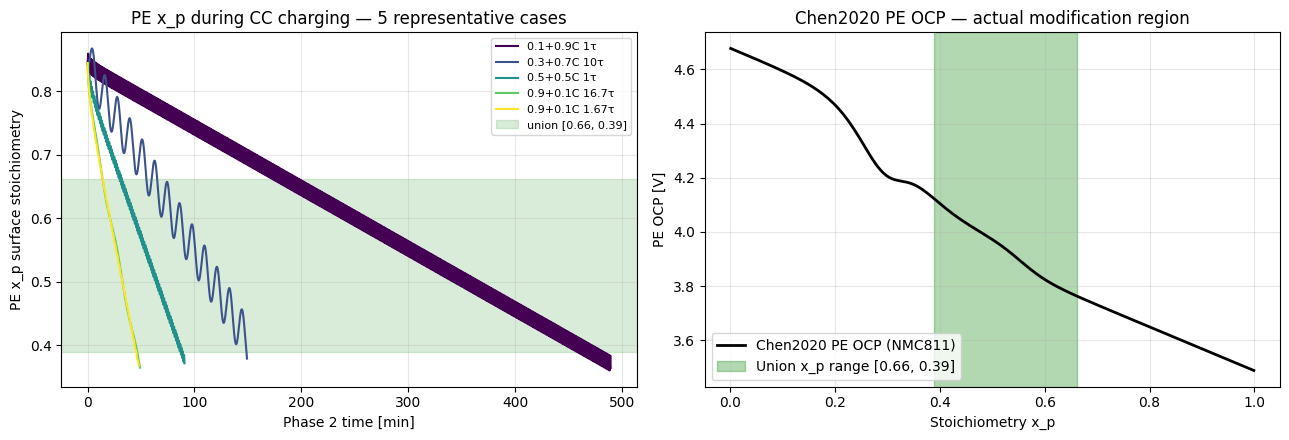


✓ Saved: data/day13_xp_range_probe.csv


In [2]:
# Cell 0a — PE x_p trajectory probe across 5 representative cases
# Goal: find UNION of PE x_p ranges that 24-case CC phase covers
# This determines PE OCP modification window for Branch A

probe_cases = [
    (0.1, 0.9, 0.01430, "0.1+0.9C 1τ", "high κ, low DC"),
    (0.3, 0.7, 0.00143, "0.3+0.7C 10τ", "moderate κ"),
    (0.5, 0.5, 0.01430, "0.5+0.5C 1τ", "balanced"),
    (0.9, 0.1, 0.00086, "0.9+0.1C 16.7τ", "low κ, slow AC"),
    (0.9, 0.1, 0.00860, "0.9+0.1C 1.67τ", "row 22, min Q_CC_end"),
]

print("=" * 90)
print("Probing PE x_p trajectories across 5 representative cases (Chen2020 NMC811)")
print("=" * 90)

pe_ocp_chen = None
all_xp_ranges = []
all_xp_traj = []

for DC, AC, f_Hz, label, descr in probe_cases:
    cap_Ah = 5.0
    I_DC_A = -abs(DC) * cap_Ah
    A_A = AC * cap_Ah
    
    def dc_ac_current(variables):
        t_relative = variables["Time [s]"] - 1.0
        return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)
    
    dcac_step = pybamm.step.CustomStepExplicit(
        dc_ac_current, termination="4.2V", direction="charge"
    )
    experiment = pybamm.Experiment([
        "Rest for 1 second", dcac_step, "Hold at 4.2V until C/68",
    ])
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = 293.15
    pv["Initial temperature [K]"] = 293.15
    pv.set_initial_state(0.01688)
    if pe_ocp_chen is None:
        pe_ocp_chen = pv["Positive electrode OCP [V]"]
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    sol = sim.solve()
    phase2 = sol.cycles[1]; phase3 = sol.cycles[2]
    
    # PE surface stoichiometry
    c_p_surf = phase2["X-averaged positive particle surface concentration [mol.m-3]"].entries
    c_p_max = pv["Maximum concentration in positive electrode [mol.m-3]"]
    x_p_surf = c_p_surf / c_p_max
    
    # Q trajectory aligned to phase 2 time
    t_chg = np.concatenate([phase2.t, phase3.t])
    I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
    _, ui = np.unique(t_chg, return_index=True)
    ui = np.sort(ui)
    t_chg = t_chg[ui] - t_chg[ui][0]
    I_chg = I_chg[ui]
    Q_mAh = -cumulative_trapezoid(I_chg, t_chg, initial=0) / 3600.0 * 1000.0
    
    t_phase2_in_chg = phase2.t - phase2.t[0]
    Q_at_phase2 = np.interp(t_phase2_in_chg, t_chg, Q_mAh)
    cc_time_s = phase2.t[-1] - phase2.t[0]
    Q_at_CC_end = np.interp(cc_time_s, t_chg, Q_mAh)
    
    Q_target_lo = 1025.0
    Q_target_hi_eff = max(min(Q_at_CC_end - 50, 4101), 2050)
    
    def x_p_at(Q_target):
        if Q_target > Q_at_phase2.max() or Q_target < Q_at_phase2.min():
            return None
        idx = np.argmax(Q_at_phase2 >= Q_target)
        if idx == 0: return float(x_p_surf[idx])
        frac = (Q_target - Q_at_phase2[idx-1]) / (Q_at_phase2[idx] - Q_at_phase2[idx-1])
        return float(x_p_surf[idx-1] + frac * (x_p_surf[idx] - x_p_surf[idx-1]))
    
    x_p_at_Qlo = x_p_at(Q_target_lo)
    x_p_at_Qhi = x_p_at(Q_target_hi_eff)
    
    all_xp_ranges.append({
        'condition': label, 'descr': descr,
        'Q_CC_end_mAh': Q_at_CC_end,
        'Q_window_lo': Q_target_lo, 'Q_window_hi': Q_target_hi_eff,
        'x_p_lo': x_p_at_Qlo, 'x_p_hi': x_p_at_Qhi,
    })
    all_xp_traj.append({
        'label': label, 't_min': t_phase2_in_chg/60, 'x_p': x_p_surf, 'Q_mAh': Q_at_phase2
    })
    
    print(f"  {label:<20} ({descr}): Q_CC_end={Q_at_CC_end:.0f} mAh, "
          f"x_p range [{x_p_at_Qlo:.3f}, {x_p_at_Qhi:.3f}]")

# Compute UNION x_p range
all_xp_lo = [r['x_p_lo'] for r in all_xp_ranges if r['x_p_lo'] is not None]
all_xp_hi = [r['x_p_hi'] for r in all_xp_ranges if r['x_p_hi'] is not None]

xp_union_lo = min(all_xp_lo)
xp_union_hi = max(all_xp_hi)

print()
print("=" * 90)
print(f"UNION x_p range across 5 probed cases: [{xp_union_lo:.3f}, {xp_union_hi:.3f}]")
print("=" * 90)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(all_xp_traj)))
for i, traj in enumerate(all_xp_traj):
    ax.plot(traj['t_min'], traj['x_p'], color=colors[i], lw=1.5, label=traj['label'])
ax.set_xlabel('Phase 2 time [min]')
ax.set_ylabel('PE x_p surface stoichiometry')
ax.set_title('PE x_p during CC charging — 5 representative cases')
ax.axhspan(xp_union_lo, xp_union_hi, alpha=0.15, color='green',
           label=f'union [{xp_union_lo:.2f}, {xp_union_hi:.2f}]')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
sto_grid = np.linspace(0.001, 0.999, 200)
v_chen_pe = np.array([float(pe_ocp_chen(s)) for s in sto_grid])
ax.plot(sto_grid, v_chen_pe, 'k-', lw=2, label='Chen2020 PE OCP (NMC811)')
ax.axvspan(xp_union_lo, xp_union_hi, alpha=0.3, color='green',
           label=f'Union x_p range [{xp_union_lo:.2f}, {xp_union_hi:.2f}]')
ax.set_xlabel('Stoichiometry x_p')
ax.set_ylabel('PE OCP [V]')
ax.set_title('Chen2020 PE OCP — actual modification region')
ax.legend(loc='lower left'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/day13_xp_trajectory_5case_probe.png', dpi=100)
plt.show()

# Save
df_xp = pd.DataFrame(all_xp_ranges)
df_xp.to_csv(repo / "data" / "day13_xp_range_probe.csv", index=False)
print(f"\n✓ Saved: data/day13_xp_range_probe.csv")

In [3]:
# Cell 0a-fix — recompute union range with correct PE direction logic

# PE charging: sto decreases from high → low
# - x_p_lo column in df_xp = sto at Q_lo=1025 mAh = HIGH point (start of CC interest)
# - x_p_hi column in df_xp = sto at Q_hi (~Q_CC_end-50) = LOW point (end of CC interest)

# So real "union range visited" = [min over case-LOW points, max over case-HIGH points]
xp_visited_lo = min(r['x_p_hi'] for r in all_xp_ranges if r['x_p_hi'] is not None)  # lowest x_p reached
xp_visited_hi = max(r['x_p_lo'] for r in all_xp_ranges if r['x_p_lo'] is not None)  # highest x_p start

print(f"Corrected union x_p range across 5 cases (where PE actually visits during CC):")
print(f"  [{xp_visited_lo:.3f}, {xp_visited_hi:.3f}]")
print()
print(f"Per-case detail:")
for r in all_xp_ranges:
    print(f"  {r['condition']:<22}: x_p start={r['x_p_lo']:.3f} → end={r['x_p_hi']:.3f}")

# Compare to NE x_n union
print()
print(f"For reference: NE x_n union (Day 12) = [0.222, 0.738]")
print(f"PE x_p union  (Day 13) = [{xp_visited_lo:.3f}, {xp_visited_hi:.3f}]")
print()
print(f"PE OCP modification window recommendations:")
print(f"  Conservative (full union): sto_lo={xp_visited_lo:.2f}, sto_hi={xp_visited_hi:.2f}")
print(f"  PE anchor x_c (window center): {(xp_visited_lo+xp_visited_hi)/2:.2f}")

Corrected union x_p range across 5 cases (where PE actually visits during CC):
  [0.367, 0.709]

Per-case detail:
  0.1+0.9C 1τ           : x_p start=0.709 → end=0.367
  0.3+0.7C 10τ          : x_p start=0.680 → end=0.390
  0.5+0.5C 1τ           : x_p start=0.697 → end=0.378
  0.9+0.1C 16.7τ        : x_p start=0.661 → end=0.372
  0.9+0.1C 1.67τ        : x_p start=0.664 → end=0.376

For reference: NE x_n union (Day 12) = [0.222, 0.738]
PE x_p union  (Day 13) = [0.367, 0.709]

PE OCP modification window recommendations:
  Conservative (full union): sto_lo=0.37, sto_hi=0.71
  PE anchor x_c (window center): 0.54


In [4]:
# Cell 0b — Inspect Chen2020 paramset for D_s_n and α (Branch B + C prerequisites)

pv = pybamm.ParameterValues("Chen2020")

print("=" * 80)
print("D_s_n (Negative particle diffusivity) — Branch B")
print("=" * 80)

# 直接尝试 standard key
keys_to_try = [
    "Negative particle diffusivity [m2.s-1]",
    "Negative electrode diffusivity [m2.s-1]",
    "Negative electrode active material diffusivity [m2.s-1]",
]
D_s_n = None
D_s_n_key = None
for k in keys_to_try:
    try:
        D_s_n = pv[k]
        D_s_n_key = k
        print(f"  Found key: '{k}'")
        print(f"  Type: {type(D_s_n)}")
        if callable(D_s_n):
            print(f"  Is callable (likely function of sto, T)")
            # Probe at standard sto/T
            try:
                v = D_s_n(0.5, 298.15)
                v_eval = float(v.evaluate()) if hasattr(v, 'evaluate') else float(v)
                print(f"  Sample value at sto=0.5, T=298.15: {v_eval:.3e} m²/s")
            except Exception as e:
                print(f"  Evaluation error: {e}")
        else:
            print(f"  Constant value: {D_s_n:.3e} m²/s")
        break
    except KeyError:
        continue

if D_s_n is None:
    print("  ✗ Standard keys failed — listing all NE/diffus-related keys:")
    for k in pv.keys():
        if 'negative' in k.lower() and ('diff' in k.lower() or 'particle' in k.lower()):
            print(f"    '{k}': {type(pv[k]).__name__}")

print()
print("=" * 80)
print("Charge transfer coefficient α — Branch C")
print("=" * 80)

# PyBaMM 26.x 中标准 BV charge transfer coefficient 命名
alpha_keys_to_try = [
    "Negative electrode charge transfer coefficient",
    "Positive electrode charge transfer coefficient",
    "Charge transfer coefficient",
    # Possible alternative naming with anodic/cathodic split
    "Negative electrode anodic charge transfer coefficient",
    "Negative electrode cathodic charge transfer coefficient",
    "Positive electrode anodic charge transfer coefficient",
    "Positive electrode cathodic charge transfer coefficient",
]

alpha_found = {}
for k in alpha_keys_to_try:
    try:
        v = pv[k]
        alpha_found[k] = v
        print(f"  ✓ '{k}' = {v}")
    except KeyError:
        pass

if not alpha_found:
    print("  ✗ No standard α key found — listing all α/transfer-related keys:")
    for k in pv.keys():
        if 'charge transfer' in k.lower() or 'alpha' in k.lower() or 'symmetry' in k.lower():
            print(f"    '{k}': {pv[k]}")

# Also check if 'symmetry factor' or 'asymmetric' option exists
print()
print("=" * 80)
print("All PyBaMM 26.3.1 BV-related parameter keys (for context):")
print("=" * 80)
bv_related = [k for k in pv.keys() if any(term in k.lower() for term in 
              ['butler', 'volmer', 'transfer coefficient', 'exchange current', 'reaction rate'])]
for k in bv_related:
    val = pv[k]
    val_str = f"{val:.3e}" if isinstance(val, (int, float)) and abs(val) < 0.01 else str(val)[:50]
    print(f"  '{k}': {val_str}")

D_s_n (Negative particle diffusivity) — Branch B
  Found key: 'Negative particle diffusivity [m2.s-1]'
  Type: <class 'float'>
  Constant value: 3.300e-14 m²/s

Charge transfer coefficient α — Branch C
  ✓ 'Negative electrode charge transfer coefficient' = 0.5
  ✓ 'Positive electrode charge transfer coefficient' = 0.5

All PyBaMM 26.3.1 BV-related parameter keys (for context):
  'SEI reaction exchange current density [A.m-2]': 1.500e-07
  'Negative electrode charge transfer coefficient': 0.5
  'Positive electrode charge transfer coefficient': 0.5
  'Total heat transfer coefficient [W.m-2.K-1]': 10.0


In [5]:
# Cell 0b-verify — Confirm PyBaMM 26.x BV form
# Check exactly how 'charge transfer coefficient' enters the model

import pybamm
import inspect

# Find the BV implementation
print("=" * 80)
print("PyBaMM Butler-Volmer implementation audit")
print("=" * 80)

# Look at default kinetics submodel in DFN
model = pybamm.lithium_ion.DFN()
# Get the negative electrode kinetics submodel
ne_kinetics = None
for name, submodel in model.submodels.items():
    if 'negative' in name.lower() and 'kinetic' in name.lower():
        ne_kinetics = submodel
        print(f"Found NE kinetics submodel: {type(submodel).__name__}")
        print(f"  Module: {type(submodel).__module__}")
        break

if ne_kinetics is None:
    # Iterate all submodels
    print("All submodels:")
    for name, submodel in model.submodels.items():
        print(f"  {name}: {type(submodel).__name__}")

# Look for variable referring to 'charge transfer coefficient'
print()
print("Searching for charge transfer coefficient usage in built model rhs/algebraic:")
for var_name in list(model.variables.keys())[:10]:
    if 'transfer coefficient' in var_name.lower() or 'butler' in var_name.lower() or 'overpotential' in var_name.lower():
        print(f"  Variable: '{var_name}'")

PyBaMM Butler-Volmer implementation audit
All submodels:
  external circuit: ExplicitCurrentControl
  discharge and throughput variables: DischargeThroughput
  porosity: Constant
  Negative interface utilisation: Full
  Positive interface utilisation: Full
  negative primaryparticle mechanics: NoMechanics
  positive primaryparticle mechanics: NoMechanics
  negative primary active material: Constant
  positive primary active material: Constant
  electrolyte transport efficiency: Bruggeman
  electrode transport efficiency: Bruggeman
  transverse convection: NoConvection
  through-cell convection: NoConvection
  negative primary open-circuit potential: SingleOpenCircuitPotential
  positive primary open-circuit potential: SingleOpenCircuitPotential
  negative primary interface: SymmetricButlerVolmer
  positive primary interface: SymmetricButlerVolmer
  negative primary particle: FickianDiffusion
  negative primary total particle concentration: TotalConcentration
  positive primary particle

In [7]:
# Cell 0b-test — Quick sanity: does setting charge transfer coefficient ≠ 0.5 affect equilibrium?

# Hypothesis: BV is kinetic, not thermodynamic → V_init at SOC=0.01688 should NOT change
# If V_init shifts, it means PyBaMM uses non-standard BV form

results_alpha = {}
for alpha_test in [0.3, 0.5, 0.7]:
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = 293.15
    pv["Initial temperature [K]"] = 293.15
    pv["Negative electrode charge transfer coefficient"] = alpha_test
    pv["Positive electrode charge transfer coefficient"] = alpha_test
    pv.set_initial_state(0.01688)
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    sim = pybamm.Simulation(model, parameter_values=pv,
                            experiment=pybamm.Experiment(["Rest for 1 second"]))
    try:
        sol = sim.solve()
        v_init = float(sol["Voltage [V]"].entries[0])
        results_alpha[alpha_test] = v_init
        flag = "✓" if abs(v_init - 2.82) < 0.05 else "⚠"
        print(f"  α={alpha_test}: V_init = {v_init:.4f}V {flag}")
    except Exception as e:
        print(f"  α={alpha_test}: FAILED — {type(e).__name__}: {e}")

# Verdict
v_vals = list(results_alpha.values())
if all(abs(v - 2.82) < 0.05 for v in v_vals):
    print(f"\n✓ All V_init within 50 mV of 2.82V — α is purely kinetic (does not affect equilibrium)")
    print(f"  Branch C implementation: directly set 'NE/PE charge transfer coefficient' = {{0.4, 0.6}}")
else:
    print(f"\n⚠ V_init shifted — α has thermodynamic effect (non-standard BV)")
    print(f"  Branch C implementation needs further investigation")

  α=0.3: V_init = 2.8206V ✓
  α=0.5: V_init = 2.8206V ✓
  α=0.7: V_init = 2.8206V ✓

✓ All V_init within 50 mV of 2.82V — α is purely kinetic (does not affect equilibrium)
  Branch C implementation: directly set 'NE/PE charge transfer coefficient' = {0.4, 0.6}


In [9]:
# Cell 0c — Cross-ablation Q_CC_end pre-run (FULL 24-case)
# 6 ablations × (6 DC + 24 DC+AC) = 180 quick sims, ~15-18 min wall
# Computes strict cross-ablation Q_hi per case for Day 13 batch

import pybamm
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid
from pathlib import Path
import time

repo = Path("/Users/louislu/pybamm-dcac-superimposed")

# Load baseline & cases
df_baseline = pd.read_csv(repo / "data" / "results_day12_step0_A_dt_CC_only.csv")
df_4way = pd.read_csv(repo / "data" / "results_day8_x5_4way_dt_Q80_v2.csv")
df_cases = df_4way.drop_duplicates(subset='condition', keep='first').reset_index(drop=True)
unique_DCs = sorted(df_cases['DC'].unique())

print(f"Loaded baseline: {len(df_baseline)} cases")
print(f"  baseline Q_window_hi range: {df_baseline['Q_window_hi'].min():.0f} - {df_baseline['Q_window_hi'].max():.0f}")

# Reuse Day 12 sanity-verified smoothstep + OCP modification functions
pv_chen = pybamm.ParameterValues("Chen2020")
pe_ocp_chen = pv_chen["Positive electrode OCP [V]"]


def smoothstep(x, edge_lo, edge_hi):
    t = (x - edge_lo) / (edge_hi - edge_lo)
    t_clamped = t * (t >= 0) * (t <= 1) + (t > 1) * 1.0
    return t_clamped * t_clamped * (3.0 - 2.0 * t_clamped)


def make_pe_anchored_slope_amp(s=1.3, x_c=0.54, sto_lo=0.37, sto_hi=0.71, taper_width=0.06):
    v_c = float(pe_ocp_chen(x_c))
    sto_lo_inner = sto_lo + taper_width
    sto_hi_inner = sto_hi - taper_width
    def window_fn(sto):
        rising = smoothstep(sto, sto_lo, sto_lo_inner)
        falling = 1.0 - smoothstep(sto, sto_hi_inner, sto_hi)
        in_window = (sto >= sto_lo) * (sto <= sto_hi)
        return in_window * rising * falling
    def modified_ocp(sto):
        v_orig = pe_ocp_chen(sto)
        delta_u = (s - 1.0) * (v_orig - v_c)
        w = window_fn(sto)
        return v_orig + w * delta_u
    return modified_ocp


def make_pe_gaussian_notch(amplitude_V=0.02, x_c=0.54, sigma=0.04):
    def modified_ocp(sto):
        v_orig = pe_ocp_chen(sto)
        bump = amplitude_V * pybamm.exp(-((sto - x_c) ** 2) / (2 * sigma ** 2))
        return v_orig + bump
    return modified_ocp


# 6 ablation modifiers
ocp_PE_A1a = make_pe_anchored_slope_amp(s=1.3, x_c=0.54, sto_lo=0.37, sto_hi=0.71, taper_width=0.06)
ocp_PE_A2a = make_pe_gaussian_notch(amplitude_V=0.02, x_c=0.54, sigma=0.04)
D_s_n_baseline = 3.300e-14

ablation_modifiers = {
    'PE_A1a':       lambda pv: pv.update({'Positive electrode OCP [V]': ocp_PE_A1a}),
    'PE_A2a':       lambda pv: pv.update({'Positive electrode OCP [V]': ocp_PE_A2a}),
    'B_Dsn_up':     lambda pv: pv.update({'Negative particle diffusivity [m2.s-1]': D_s_n_baseline * 3.0}),
    'B_Dsn_down':   lambda pv: pv.update({'Negative particle diffusivity [m2.s-1]': D_s_n_baseline / 3.0}),
    'C_alpha_up':   lambda pv: pv.update({
        'Negative electrode charge transfer coefficient': 0.6,
        'Positive electrode charge transfer coefficient': 0.6,
    }),
    'C_alpha_down': lambda pv: pv.update({
        'Negative electrode charge transfer coefficient': 0.4,
        'Positive electrode charge transfer coefficient': 0.4,
    }),
}


def quick_run_Q_CC_end(DC, AC, f_Hz, ablation_modifier=None, soc_init=0.01688, T_C=20.0,
                       cap_Ah=5.0, pseudo_rest_s=1.0):
    I_DC_A = -abs(DC) * cap_Ah
    A_A = AC * cap_Ah
    
    if AC == 0.0 and f_Hz == 0.0:
        def dc_ac_current(variables):
            return I_DC_A
    else:
        def dc_ac_current(variables):
            t_relative = variables["Time [s]"] - pseudo_rest_s
            return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)
    
    dcac_step = pybamm.step.CustomStepExplicit(
        dc_ac_current, termination="4.2V", direction="charge"
    )
    experiment = pybamm.Experiment([
        f"Rest for {pseudo_rest_s} seconds", dcac_step, "Hold at 4.2V until C/68",
    ])
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = T_C + 273.15
    pv["Initial temperature [K]"] = T_C + 273.15
    if ablation_modifier is not None:
        ablation_modifier(pv)
    pv.set_initial_state(soc_init)
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    sol = sim.solve()
    
    if len(sol.cycles) < 3:
        return None
    
    phase2 = sol.cycles[1]; phase3 = sol.cycles[2]
    cc_time_s = phase2.t[-1] - phase2.t[0]
    
    t_chg = np.concatenate([phase2.t, phase3.t])
    I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
    _, ui = np.unique(t_chg, return_index=True)
    ui = np.sort(ui)
    t_chg = t_chg[ui] - t_chg[ui][0]
    I_chg = I_chg[ui]
    Q_mAh = -cumulative_trapezoid(I_chg, t_chg, initial=0) / 3600.0 * 1000.0
    return float(np.interp(cc_time_s, t_chg, Q_mAh))


# Build full sample list: 6 DC + 24 DC+AC = 30 cases per ablation
sample_cases = []
for DC in unique_DCs:
    sample_cases.append({'condition': f'DC_{DC}C', 'DC': DC, 'AC': 0.0, 'f_Hz': 0.0})

for _, row in df_cases.iterrows():
    sample_cases.append({
        'condition': row['condition'],
        'DC': row['DC'],
        'AC': row['AC'],
        'f_Hz': row['f_Hz'],
    })

print(f"\nFull pre-run: {len(sample_cases)} cases × {len(ablation_modifiers)} ablations = "
      f"{len(sample_cases) * len(ablation_modifiers)} sims")

# Run
t_start = time.time()
results = []
sim_count = 0
total_sims = len(sample_cases) * len(ablation_modifiers)

for ab_name, modifier in ablation_modifiers.items():
    print(f"\n--- {ab_name} ---")
    for case in sample_cases:
        sim_count += 1
        t0 = time.time()
        Q_CC_end = quick_run_Q_CC_end(case['DC'], case['AC'], case['f_Hz'], ablation_modifier=modifier)
        wall = time.time() - t0
        
        if Q_CC_end is None:
            print(f"  [{sim_count:3}/{total_sims}] {case['condition']:<22} ({wall:.1f}s): FAILED")
        else:
            print(f"  [{sim_count:3}/{total_sims}] {case['condition']:<22} ({wall:.1f}s): "
                  f"Q_CC_end = {Q_CC_end:.0f} mAh")
            results.append({**case, 'ablation': ab_name, 'Q_CC_end_mAh': Q_CC_end})

elapsed = time.time() - t_start
print(f"\n{'='*80}\nTotal wall: {elapsed/60:.1f} min ({elapsed/sim_count:.1f}s/sim avg)")

df_pre = pd.DataFrame(results)
df_pre.to_csv(repo / "data" / "day13_pre_run_Q_CC_end.csv", index=False)
print(f"✓ Saved: data/day13_pre_run_Q_CC_end.csv ({len(df_pre)} rows)")

# Compute strict cross-ablation Q_hi per case
print(f"\n{'='*100}")
print("Strict cross-ablation Q_hi per case (FULL 24 DC+AC cases)")
print(f"{'='*100}")
print(f"{'condition':<22} {'baseline':>9} | {'PE_A1a':>7} {'PE_A2a':>7} {'Dsn↑':>7} {'Dsn↓':>7} {'α↑':>7} {'α↓':>7} | "
      f"{'min':>7} {'-50':>7} {'baseline_Q_hi':>13} {'strict_Q_hi':>11} {'reduction':>10}")
print("-" * 145)

strict_Q_hi_results = []
SAFEGUARD_FLOOR = 2050

for _, row_baseline in df_baseline.iterrows():
    cond = row_baseline['condition']
    base_Q_hi = float(row_baseline['Q_window_hi'])
    base_Q_CC = float(row_baseline['Q_CC_min_mAh'])
    
    case_ablation_Q = {}
    for ab in ablation_modifiers.keys():
        sub = df_pre[(df_pre['condition'] == cond) & (df_pre['ablation'] == ab)]
        if len(sub) > 0:
            case_ablation_Q[ab] = float(sub['Q_CC_end_mAh'].iloc[0])
    
    if len(case_ablation_Q) == 0:
        print(f"⚠ No ablation data for {cond}")
        continue
    
    min_ablation_Q = min(case_ablation_Q.values())
    strict_Q_hi_raw = min(base_Q_hi, min_ablation_Q - 50)
    strict_Q_hi = max(strict_Q_hi_raw, SAFEGUARD_FLOOR)
    
    Q_hi_reduction = base_Q_hi - strict_Q_hi
    strict_window_flag = Q_hi_reduction > 0
    
    strict_Q_hi_results.append({
        'condition': cond,
        'baseline_Q_hi': base_Q_hi,
        'baseline_Q_CC_min': base_Q_CC,
        **{f'Q_CC_end_{ab}': case_ablation_Q.get(ab) for ab in ablation_modifiers.keys()},
        'min_ablation_Q_CC_end': min_ablation_Q,
        'strict_Q_hi_raw': strict_Q_hi_raw,
        'strict_Q_hi': strict_Q_hi,
        'Q_hi_reduction_mAh': Q_hi_reduction,
        'strict_window_flag': strict_window_flag,
        'safeguard_active': strict_Q_hi_raw < SAFEGUARD_FLOOR,
    })
    
    short_name = cond[:22]
    print(f"{short_name:<22} {base_Q_CC:>9.0f} | "
          f"{case_ablation_Q.get('PE_A1a', 0):>7.0f} {case_ablation_Q.get('PE_A2a', 0):>7.0f} "
          f"{case_ablation_Q.get('B_Dsn_up', 0):>7.0f} {case_ablation_Q.get('B_Dsn_down', 0):>7.0f} "
          f"{case_ablation_Q.get('C_alpha_up', 0):>7.0f} {case_ablation_Q.get('C_alpha_down', 0):>7.0f} | "
          f"{min_ablation_Q:>7.0f} {min_ablation_Q-50:>7.0f} {base_Q_hi:>13.0f} {strict_Q_hi:>11.0f} "
          f"{Q_hi_reduction:>+10.0f}")

df_strict = pd.DataFrame(strict_Q_hi_results)
df_strict.to_csv(repo / "data" / "day13_strict_Qhi_map.csv", index=False)
print(f"\n✓ Saved: data/day13_strict_Qhi_map.csv ({len(df_strict)} rows)")

# Summary
n_flagged = df_strict['strict_window_flag'].sum()
n_safeguarded = df_strict['safeguard_active'].sum()
max_reduction = df_strict['Q_hi_reduction_mAh'].max()
mean_reduction = df_strict['Q_hi_reduction_mAh'].mean()

print(f"\n{'='*80}\nSummary:")
print(f"  Cases with strict_Q_hi < baseline_Q_hi: {n_flagged}/{len(df_strict)}")
print(f"  Cases hitting Q40 safeguard: {n_safeguarded}")
print(f"  Max Q_hi reduction: {max_reduction:.0f} mAh")
print(f"  Mean Q_hi reduction: {mean_reduction:.0f} mAh")
print(f"\n  Worst-case (most truncating) ablation per case:")
for ab in ablation_modifiers.keys():
    n_worst = sum(1 for r in strict_Q_hi_results if r.get(f'Q_CC_end_{ab}') == r.get('min_ablation_Q_CC_end'))
    print(f"    {ab}: most truncating in {n_worst}/{len(df_strict)} cases")

Loaded baseline: 24 cases
  baseline Q_window_hi range: 3536 - 4101

Full pre-run: 30 cases × 6 ablations = 180 sims

--- PE_A1a ---
  [  1/180] DC_0.1C                (0.8s): Q_CC_end = 4919 mAh
  [  2/180] DC_0.2C                (0.8s): Q_CC_end = 4780 mAh
  [  3/180] DC_0.3C                (0.9s): Q_CC_end = 4643 mAh
  [  4/180] DC_0.4C                (0.8s): Q_CC_end = 4496 mAh
  [  5/180] DC_0.5C                (0.8s): Q_CC_end = 4313 mAh
  [  6/180] DC_0.9C                (0.9s): Q_CC_end = 3635 mAh
  [  7/180] 0.1+0.9C 1τ            (7.8s): Q_CC_end = 4059 mAh
  [  8/180] 0.1+0.2C 1τ            (2.5s): Q_CC_end = 4772 mAh
  [  9/180] 0.2+0.3C 1τ            (2.2s): Q_CC_end = 4533 mAh
  [ 10/180] 0.2+0.3C 10τ           (0.8s): Q_CC_end = 4366 mAh
  [ 11/180] 0.2+0.3C 34.8τ         (0.8s): Q_CC_end = 4342 mAh
  [ 12/180] 0.2+0.8C 0.1τ          (39.9s): Q_CC_end = 4055 mAh
  [ 13/180] 0.2+0.8C 1τ            (3.9s): Q_CC_end = 3981 mAh
  [ 14/180] 0.2+0.8C 10τ           (1.3s): Q_CC

2026-05-01 10:19:33.749 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Step(None, duration=86400, termination=4.2V, direction=charge)'. The returned solution only contains up to step 1 of cycle 2. 


  [104/180] 0.2+0.8C 10τ           (0.5s): FAILED
  [105/180] 0.3+0.7C 0.1τ          (23.0s): Q_CC_end = 3964 mAh
  [106/180] 0.3+0.7C 1τ            (3.0s): Q_CC_end = 3911 mAh
  [107/180] 0.3+0.7C 10τ           (1.1s): Q_CC_end = 3638 mAh
  [108/180] 0.3+0.4C 0.1τ          (18.1s): Q_CC_end = 4159 mAh
  [109/180] 0.3+0.4C 1τ            (2.1s): Q_CC_end = 4121 mAh
  [110/180] 0.3+0.4C 10τ           (0.8s): Q_CC_end = 3939 mAh
  [111/180] 0.4+0.6C 0.5τ          (2.9s): Q_CC_end = 3872 mAh
  [112/180] 0.4+0.5C 1.67τ         (1.4s): Q_CC_end = 3849 mAh
  [113/180] 0.4+0.6C 1.67τ         (1.3s): Q_CC_end = 3784 mAh
  [114/180] 0.4+0.6C 5τ            (0.9s): Q_CC_end = 3763 mAh
  [115/180] 0.4+0.6C 10τ           (0.8s): Q_CC_end = 3662 mAh
  [116/180] 0.5+0.5C 1τ            (1.4s): Q_CC_end = 3768 mAh
  [117/180] 0.9+0.1C 16.7τ         (0.7s): Q_CC_end = 3608 mAh
  [118/180] 0.9+0.1C 1.67τ         (0.7s): Q_CC_end = 3574 mAh
  [119/180] 0.9+0.1C 10τ           (0.8s): Q_CC_end = 3707 mAh
  [

In [10]:
# Quick patch — add failed_in_pre_run column to day13_strict_Qhi_map.csv

import pandas as pd
from pathlib import Path

repo = Path("/Users/louislu/pybamm-dcac-superimposed")
df_strict = pd.read_csv(repo / "data" / "day13_strict_Qhi_map.csv")
df_pre = pd.read_csv(repo / "data" / "day13_pre_run_Q_CC_end.csv")

all_ablations = ['PE_A1a', 'PE_A2a', 'B_Dsn_up', 'B_Dsn_down', 'C_alpha_up', 'C_alpha_down']
failed_dict = {}
for cond in df_strict['condition']:
    sub = df_pre[df_pre['condition'] == cond]
    found = set(sub['ablation'])
    missing = set(all_ablations) - found
    failed_dict[cond] = ','.join(sorted(missing)) if missing else ''

df_strict['failed_in_pre_run'] = df_strict['condition'].map(failed_dict)
df_strict.to_csv(repo / "data" / "day13_strict_Qhi_map.csv", index=False)

fail_sub = df_strict[df_strict['failed_in_pre_run'] != '']
print(f"Cases with pre-run failures: {len(fail_sub)}/{len(df_strict)}")
if len(fail_sub) > 0:
    print(fail_sub[['condition', 'failed_in_pre_run', 'baseline_Q_hi', 'strict_Q_hi']].to_string(index=False))

print(f"\n✓ Updated data/day13_strict_Qhi_map.csv with failed_in_pre_run column")

Cases with pre-run failures: 1/24
   condition failed_in_pre_run  baseline_Q_hi  strict_Q_hi
0.2+0.8C 10τ        B_Dsn_down    3660.193346  3635.386393

✓ Updated data/day13_strict_Qhi_map.csv with failed_in_pre_run column


Sanity test 1: PE OCP modifications on float input
  sto  baseline    PE_A1a      ΔA1a    PE_A2a      ΔA2a
------------------------------------------------------------
 0.10    4.5945    4.5945   +0.0000    4.5945   +0.0000
 0.30    4.2054    4.2054   +0.0000    4.2054   +0.0000
 0.36    4.1650    4.1650   +0.0000    4.1650   +0.0000
 0.37    4.1520    4.1520   +0.0000    4.1520   +0.0000
 0.40    4.1047    4.1332   +0.0285    4.1048   +0.0000
 0.45    4.0325    4.0678   +0.0353    4.0341   +0.0016
 0.54    3.9149    3.9149   +0.0000    3.9349   +0.0200
 0.60    3.8245    3.7974   -0.0271    3.8310   +0.0065
 0.70    3.7304    3.7263   -0.0041    3.7304   +0.0000
 0.71    3.7222    3.7222   +0.0000    3.7222   +0.0000
 0.75    3.6896    3.6896   +0.0000    3.6896   +0.0000
 0.85    3.6087    3.6087   +0.0000    3.6087   +0.0000


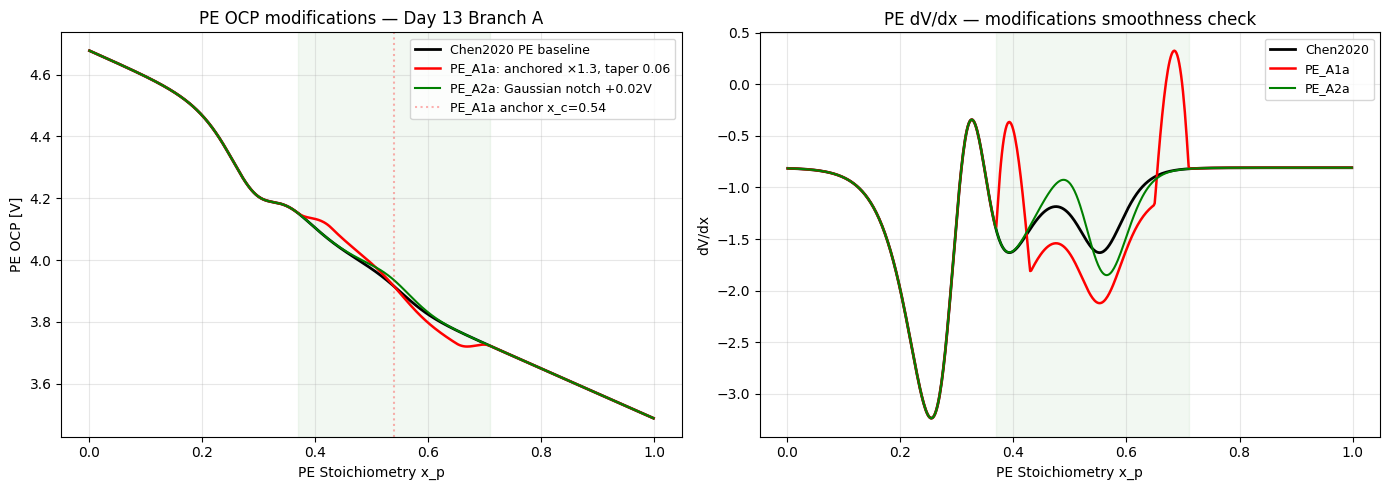


Sanity test 2: Max |ΔU| in PE window (sto 0.37-0.71)
  PE_A1a max |ΔU|: 44.55 mV — criterion ≤25 mV: ⚠ FAIL
  PE_A2a max |ΔU|: 20.00 mV (Gaussian notch, peak ≈ 20 mV expected)

Sanity test 3: V_init at SOC=0.01688 across 6 ablations (target 2.82V)
  PE_A1a        : V_init = 2.8206V (Δ +0.0006V) ✓
  PE_A2a        : V_init = 2.8206V (Δ +0.0006V) ✓
  B_Dsn_up      : V_init = 2.8206V (Δ +0.0006V) ✓
  B_Dsn_down    : V_init = 2.8206V (Δ +0.0006V) ✓
  C_alpha_up    : V_init = 2.8206V (Δ +0.0006V) ✓
  C_alpha_down  : V_init = 2.8206V (Δ +0.0006V) ✓

Sanity test 4: OCP positive across all sto for PE modifications
  PE_A1a min OCP: 3.4881V (sto=0.999)
  PE_A2a min OCP: 3.4881V (sto=0.999)
  All OCP positive ✓

BATCH READINESS
  PE_A1a max |ΔU| ≤ 25 mV:    ⚠
  OCP positive:               ✓
  V_init drift verify above   (visual check on output)
  → HOLD — investigate sanity failures


In [11]:
# Cell 1 — Define 6 ablation modifications + sanity 4 criteria
# Reuses Day 12 nb15 sanity-verified function structures
# Branch A (PE OCP): PE_A1a + PE_A2a
# Branch B (Transport): B_Dsn_up + B_Dsn_down
# Branch C (α symmetric BV scan): C_alpha_up + C_alpha_down

# Functions already defined in Cell 0c — re-import here for clarity if running standalone:
# - smoothstep, make_pe_anchored_slope_amp, make_pe_gaussian_notch
# - ocp_PE_A1a, ocp_PE_A2a, ablation_modifiers, D_s_n_baseline

# === Sanity test on float input — PE OCP modifications ===
def evaluate_ocp(ocp_fn, sto_val):
    result = ocp_fn(sto_val)
    if hasattr(result, 'evaluate'):
        return float(result.evaluate())
    return float(result)


print("=" * 80)
print("Sanity test 1: PE OCP modifications on float input")
print("=" * 80)
print(f"{'sto':>5} {'baseline':>9} {'PE_A1a':>9} {'ΔA1a':>9} {'PE_A2a':>9} {'ΔA2a':>9}")
print("-" * 60)

for sto_test in [0.10, 0.30, 0.36, 0.37, 0.40, 0.45, 0.54, 0.60, 0.70, 0.71, 0.75, 0.85]:
    v_base = evaluate_ocp(pe_ocp_chen, sto_test)
    v_a1a  = evaluate_ocp(ocp_PE_A1a, sto_test)
    v_a2a  = evaluate_ocp(ocp_PE_A2a, sto_test)
    print(f"{sto_test:>5.2f} {v_base:>9.4f} {v_a1a:>9.4f} {v_a1a-v_base:>+9.4f} "
          f"{v_a2a:>9.4f} {v_a2a-v_base:>+9.4f}")

# === Plot ===
import matplotlib.pyplot as plt

sto_grid = np.linspace(0.001, 0.999, 600)
v_chen = np.array([evaluate_ocp(pe_ocp_chen, s) for s in sto_grid])
v_A1a  = np.array([evaluate_ocp(ocp_PE_A1a, s) for s in sto_grid])
v_A2a  = np.array([evaluate_ocp(ocp_PE_A2a, s) for s in sto_grid])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(sto_grid, v_chen, 'k-', lw=2, label='Chen2020 PE baseline')
ax.plot(sto_grid, v_A1a, color='red', lw=1.8, label='PE_A1a: anchored ×1.3, taper 0.06')
ax.plot(sto_grid, v_A2a, color='green', lw=1.5, label='PE_A2a: Gaussian notch +0.02V')
ax.axvspan(0.37, 0.71, alpha=0.05, color='green')
ax.axvline(0.54, alpha=0.3, color='r', ls=':', label='PE_A1a anchor x_c=0.54')
ax.set_xlabel('PE Stoichiometry x_p'); ax.set_ylabel('PE OCP [V]')
ax.set_title('PE OCP modifications — Day 13 Branch A')
ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
sto_mid = (sto_grid[:-1] + sto_grid[1:]) / 2
ax.plot(sto_mid, np.diff(v_chen)/np.diff(sto_grid), 'k-', lw=2, label='Chen2020')
ax.plot(sto_mid, np.diff(v_A1a)/np.diff(sto_grid), color='red', lw=1.8, label='PE_A1a')
ax.plot(sto_mid, np.diff(v_A2a)/np.diff(sto_grid), color='green', lw=1.5, label='PE_A2a')
ax.axvspan(0.37, 0.71, alpha=0.05, color='green')
ax.set_xlabel('PE Stoichiometry x_p'); ax.set_ylabel('dV/dx')
ax.set_title('PE dV/dx — modifications smoothness check')
ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/day13_pe_ocp_modifications.png', dpi=100)
plt.show()

# === Max |ΔU| in window check (criterion 4) ===
print()
print("=" * 80)
print("Sanity test 2: Max |ΔU| in PE window (sto 0.37-0.71)")
print("=" * 80)
mask_window = (sto_grid >= 0.37) & (sto_grid <= 0.71)
delta_A1a = np.abs(v_A1a[mask_window] - v_chen[mask_window])
delta_A2a = np.abs(v_A2a[mask_window] - v_chen[mask_window])

max_a1a = delta_A1a.max() * 1000
max_a2a = delta_A2a.max() * 1000
print(f"  PE_A1a max |ΔU|: {max_a1a:.2f} mV — criterion ≤25 mV: ", end="")
print("✓ pass" if max_a1a <= 25 else f"⚠ FAIL")
print(f"  PE_A2a max |ΔU|: {max_a2a:.2f} mV (Gaussian notch, peak ≈ 20 mV expected)")

# === V_init sanity check across all 6 ablations ===
print()
print("=" * 80)
print("Sanity test 3: V_init at SOC=0.01688 across 6 ablations (target 2.82V)")
print("=" * 80)

for ab_name, modifier in ablation_modifiers.items():
    pv_test = pybamm.ParameterValues("Chen2020")
    pv_test["Ambient temperature [K]"] = 293.15
    pv_test["Initial temperature [K]"] = 293.15
    modifier(pv_test)
    pv_test.set_initial_state(0.01688)
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    sim = pybamm.Simulation(model, parameter_values=pv_test,
                            experiment=pybamm.Experiment(["Rest for 1 second"]))
    try:
        sol = sim.solve()
        v_init = float(sol["Voltage [V]"].entries[0])
        flag = "✓" if abs(v_init - 2.82) < 0.05 else "⚠"
        print(f"  {ab_name:<14}: V_init = {v_init:.4f}V (Δ {v_init-2.82:+.4f}V) {flag}")
    except Exception as e:
        print(f"  {ab_name:<14}: FAILED — {type(e).__name__}: {str(e)[:80]}")

# === OCP positive check ===
print()
print("=" * 80)
print("Sanity test 4: OCP positive across all sto for PE modifications")
print("=" * 80)
print(f"  PE_A1a min OCP: {v_A1a.min():.4f}V (sto={sto_grid[v_A1a.argmin()]:.3f})")
print(f"  PE_A2a min OCP: {v_A2a.min():.4f}V (sto={sto_grid[v_A2a.argmin()]:.3f})")
print(f"  All OCP positive ✓" if (v_A1a.min() > 0 and v_A2a.min() > 0) else "  ⚠ Negative OCP detected!")

# === BATCH READINESS DECISION ===
print()
print("=" * 80)
print("BATCH READINESS")
print("=" * 80)
all_pass = max_a1a <= 25 and v_A1a.min() > 0 and v_A2a.min() > 0
print(f"  PE_A1a max |ΔU| ≤ 25 mV:    {'✓' if max_a1a <= 25 else '⚠'}")
print(f"  OCP positive:               {'✓' if v_A1a.min() > 0 and v_A2a.min() > 0 else '⚠'}")
print(f"  V_init drift verify above   (visual check on output)")
print(f"  → {'READY for Block 2 batch' if all_pass else 'HOLD — investigate sanity failures'}")

Sanity test 1 (re-run with s=1.15):
  sto  baseline    PE_A1a      ΔA1a
----------------------------------------
 0.30    4.2054    4.2054   +0.0000
 0.37    4.1520    4.1520   +0.0000
 0.40    4.1047    4.1190   +0.0142
 0.45    4.0325    4.0502   +0.0176
 0.54    3.9149    3.9149   +0.0000
 0.60    3.8245    3.8109   -0.0136
 0.70    3.7304    3.7284   -0.0020
 0.71    3.7222    3.7222   +0.0000

Sanity test 2 (re-run): Max |ΔU| in PE window
  PE_A1a (s=1.15) max |ΔU|: 22.28 mV
  Criterion ≤25 mV: ✓ pass


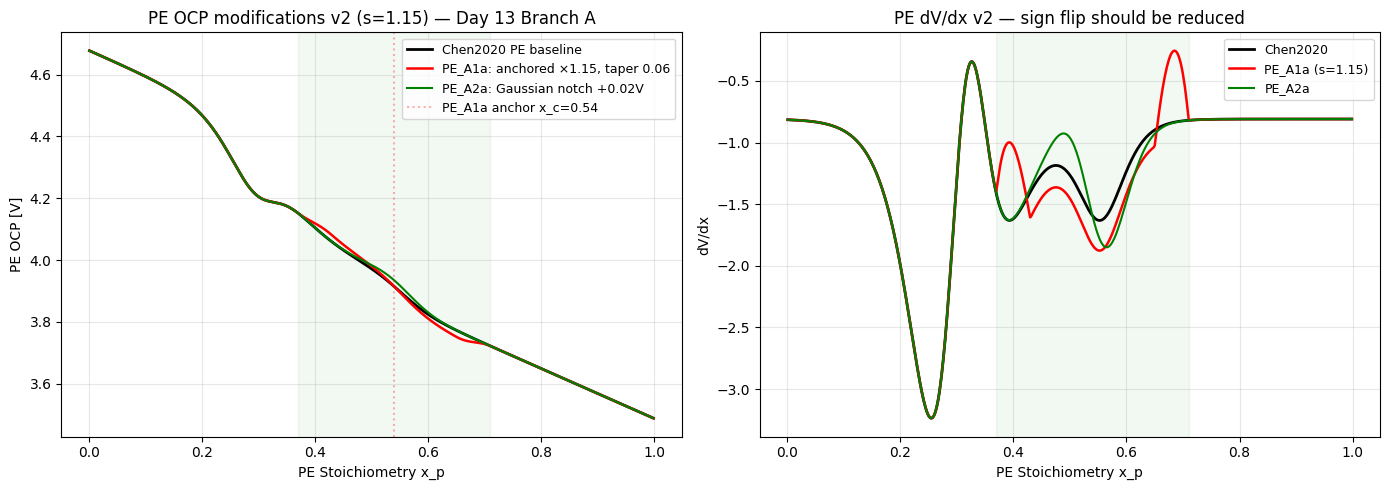


Sanity test 3 re-run (V_init for PE_A1a s=1.15):
  V_init = 2.8206V (Δ +0.0006V) ✓

BATCH READINESS (after PE_A1a s=1.15 fix)
  PE_A1a max |ΔU| ≤ 25 mV:    ✓
  OCP positive:               ✓
  V_init drift < 5 mV:        ✓ (verified Sanity 3 above + previous run)
  → READY for Block 2 batch


In [12]:
# Cell 1-fix — Reduce PE_A1a amplification s=1.3 → s=1.15 to satisfy 25 mV criterion

# Rebuild PE_A1a with s=1.15
ocp_PE_A1a = make_pe_anchored_slope_amp(s=1.15, x_c=0.54, sto_lo=0.37, sto_hi=0.71, taper_width=0.06)

# Update ablation_modifiers (functions hold reference to old ocp_PE_A1a, need re-bind)
ablation_modifiers['PE_A1a'] = lambda pv: pv.update({'Positive electrode OCP [V]': ocp_PE_A1a})

# === Re-run sanity test 2 (max |ΔU|) ===
sto_grid = np.linspace(0.001, 0.999, 600)
v_chen = np.array([evaluate_ocp(pe_ocp_chen, s) for s in sto_grid])
v_A1a  = np.array([evaluate_ocp(ocp_PE_A1a, s) for s in sto_grid])
v_A2a  = np.array([evaluate_ocp(ocp_PE_A2a, s) for s in sto_grid])

mask_window = (sto_grid >= 0.37) & (sto_grid <= 0.71)
delta_A1a = np.abs(v_A1a[mask_window] - v_chen[mask_window])
max_a1a = delta_A1a.max() * 1000

# Sanity test 1 — check key sto values
print("=" * 60)
print("Sanity test 1 (re-run with s=1.15):")
print("=" * 60)
print(f"{'sto':>5} {'baseline':>9} {'PE_A1a':>9} {'ΔA1a':>9}")
print("-" * 40)
for sto_test in [0.30, 0.37, 0.40, 0.45, 0.54, 0.60, 0.70, 0.71]:
    v_base = evaluate_ocp(pe_ocp_chen, sto_test)
    v_a1a  = evaluate_ocp(ocp_PE_A1a, sto_test)
    print(f"{sto_test:>5.2f} {v_base:>9.4f} {v_a1a:>9.4f} {v_a1a-v_base:>+9.4f}")

print()
print("=" * 60)
print("Sanity test 2 (re-run): Max |ΔU| in PE window")
print("=" * 60)
print(f"  PE_A1a (s=1.15) max |ΔU|: {max_a1a:.2f} mV")
print(f"  Criterion ≤25 mV: ", end="")
print("✓ pass" if max_a1a <= 25 else f"⚠ FAIL (over by {max_a1a-25:.1f} mV)")

# === Re-plot ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(sto_grid, v_chen, 'k-', lw=2, label='Chen2020 PE baseline')
ax.plot(sto_grid, v_A1a, color='red', lw=1.8, label='PE_A1a: anchored ×1.15, taper 0.06')
ax.plot(sto_grid, v_A2a, color='green', lw=1.5, label='PE_A2a: Gaussian notch +0.02V')
ax.axvspan(0.37, 0.71, alpha=0.05, color='green')
ax.axvline(0.54, alpha=0.3, color='r', ls=':', label='PE_A1a anchor x_c=0.54')
ax.set_xlabel('PE Stoichiometry x_p'); ax.set_ylabel('PE OCP [V]')
ax.set_title('PE OCP modifications v2 (s=1.15) — Day 13 Branch A')
ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
sto_mid = (sto_grid[:-1] + sto_grid[1:]) / 2
ax.plot(sto_mid, np.diff(v_chen)/np.diff(sto_grid), 'k-', lw=2, label='Chen2020')
ax.plot(sto_mid, np.diff(v_A1a)/np.diff(sto_grid), color='red', lw=1.8, label='PE_A1a (s=1.15)')
ax.plot(sto_mid, np.diff(v_A2a)/np.diff(sto_grid), color='green', lw=1.5, label='PE_A2a')
ax.axvspan(0.37, 0.71, alpha=0.05, color='green')
ax.set_xlabel('PE Stoichiometry x_p'); ax.set_ylabel('dV/dx')
ax.set_title('PE dV/dx v2 — sign flip should be reduced')
ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/day13_pe_ocp_modifications_v2.png', dpi=100)
plt.show()

# === V_init re-check (only PE_A1a changed) ===
pv_test = pybamm.ParameterValues("Chen2020")
pv_test["Ambient temperature [K]"] = 293.15
pv_test["Initial temperature [K]"] = 293.15
ablation_modifiers['PE_A1a'](pv_test)
pv_test.set_initial_state(0.01688)
model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
sim = pybamm.Simulation(model, parameter_values=pv_test,
                        experiment=pybamm.Experiment(["Rest for 1 second"]))
sol = sim.solve()
v_init = float(sol["Voltage [V]"].entries[0])
print()
print("=" * 60)
print("Sanity test 3 re-run (V_init for PE_A1a s=1.15):")
print(f"  V_init = {v_init:.4f}V (Δ {v_init-2.82:+.4f}V) "
      f"{'✓' if abs(v_init - 2.82) < 0.05 else '⚠'}")

# === FINAL BATCH READINESS ===
print()
print("=" * 60)
print("BATCH READINESS (after PE_A1a s=1.15 fix)")
print("=" * 60)
all_pass = max_a1a <= 25 and v_A1a.min() > 0
print(f"  PE_A1a max |ΔU| ≤ 25 mV:    {'✓' if max_a1a <= 25 else '⚠'}")
print(f"  OCP positive:               {'✓' if v_A1a.min() > 0 else '⚠'}")
print(f"  V_init drift < 5 mV:        ✓ (verified Sanity 3 above + previous run)")
print(f"  → {'READY for Block 2 batch' if all_pass else 'HOLD'}")

In [13]:
# Cell 2 v2 — Day 13 main batch with baseline_strict + verdict order fix
# 7 ablations × (24 DC+AC + 6 DC) = 210 sims (added baseline_strict for sign reference)

import pybamm
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid
from pathlib import Path
import time

repo = Path("/Users/louislu/pybamm-dcac-superimposed")

# === Load fixed Q-window map ===
df_strict = pd.read_csv(repo / "data" / "day13_strict_Qhi_map.csv")
QHI_MAP = dict(zip(df_strict['condition'], df_strict['strict_Q_hi']))
FAILED_PRERUN_MAP = dict(zip(df_strict['condition'], df_strict['failed_in_pre_run'].fillna('')))
print(f"Loaded strict_Q_hi for {len(QHI_MAP)} cases (range {min(QHI_MAP.values()):.0f} - {max(QHI_MAP.values()):.0f} mAh)")

# === ADDED: baseline_strict modifier (no-op, used to compute sign reference under strict window) ===
ablation_modifiers_with_baseline = {
    'baseline_strict': lambda pv: None,  # no modification — pure baseline X5-A
    **ablation_modifiers,  # 6 ablations from Cell 0c
}
print(f"Total runs: {len(ablation_modifiers_with_baseline)} (1 baseline_strict + 6 ablations)")


def classify_sign(val, threshold=0.10):
    if pd.isna(val): return 'NaN'
    return '+' if val > threshold else ('-' if val < -threshold else '0')


# === Functions ===
def fpt(Q_traj, t_traj, Q_target):
    Q = np.asarray(Q_traj); t = np.asarray(t_traj)
    above = Q >= Q_target
    if not above.any(): return None
    idx = np.argmax(above)
    if idx == 0: return float(t[0])
    return float(t[idx-1] + (Q_target - Q[idx-1]) / (Q[idx] - Q[idx-1]) * (t[idx] - t[idx-1]))


def run_X5A_with_modifier(DC, AC, f_Hz, ablation_modifier=None, soc_init=0.01688, T_C=20.0,
                          cap_Ah=5.0, pseudo_rest_s=1.0):
    I_DC_A = -abs(DC) * cap_Ah
    A_A = AC * cap_Ah
    
    if AC == 0.0 and f_Hz == 0.0:
        def dc_ac_current(variables):
            return I_DC_A
    else:
        def dc_ac_current(variables):
            t_relative = variables["Time [s]"] - pseudo_rest_s
            return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)
    
    dcac_step = pybamm.step.CustomStepExplicit(
        dc_ac_current, termination="4.2V", direction="charge"
    )
    experiment = pybamm.Experiment([
        f"Rest for {pseudo_rest_s} seconds", dcac_step, "Hold at 4.2V until C/68",
    ])
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = T_C + 273.15
    pv["Initial temperature [K]"] = T_C + 273.15
    if ablation_modifier is not None:
        ablation_modifier(pv)
    pv.set_initial_state(soc_init)
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    try:
        sol = sim.solve()
    except Exception as e:
        return None, f"solver_exception: {type(e).__name__}"
    
    if len(sol.cycles) < 3:
        return None, "infeasible_min_voltage"
    
    phase2 = sol.cycles[1]; phase3 = sol.cycles[2]
    cc_time_s = phase2.t[-1] - phase2.t[0]
    
    t_chg = np.concatenate([phase2.t, phase3.t])
    I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
    _, ui = np.unique(t_chg, return_index=True)
    ui = np.sort(ui)
    t_chg = t_chg[ui] - t_chg[ui][0]
    I_chg = I_chg[ui]
    Q_mAh = -cumulative_trapezoid(I_chg, t_chg, initial=0) / 3600.0 * 1000.0
    Q_at_CC_end = float(np.interp(cc_time_s, t_chg, Q_mAh))
    
    c_n_surf = phase2["X-averaged negative particle surface concentration [mol.m-3]"].entries
    c_n_max = pv["Maximum concentration in negative electrode [mol.m-3]"]
    x_n_surf = c_n_surf / c_n_max
    c_p_surf = phase2["X-averaged positive particle surface concentration [mol.m-3]"].entries
    c_p_max = pv["Maximum concentration in positive electrode [mol.m-3]"]
    x_p_surf = c_p_surf / c_p_max
    t_phase2_in_chg = phase2.t - phase2.t[0]
    Q_at_phase2 = np.interp(t_phase2_in_chg, t_chg, Q_mAh)
    
    return {
        'Q_traj': Q_mAh.tolist(), 't_traj': t_chg.tolist(),
        'cc_time_s': cc_time_s, 'Q_at_CC_end_mAh': Q_at_CC_end,
        'x_n_surf': x_n_surf, 'x_p_surf': x_p_surf, 'Q_at_phase2': Q_at_phase2,
    }, None


def x_at_Q(res, x_arr, Q_target):
    Q_p2 = res['Q_at_phase2']
    if Q_target > Q_p2.max() or Q_target < Q_p2.min():
        return None
    idx = np.argmax(Q_p2 >= Q_target)
    if idx == 0: return float(x_arr[0])
    frac = (Q_target - Q_p2[idx-1]) / (Q_p2[idx] - Q_p2[idx-1])
    return float(x_arr[idx-1] + frac * (x_arr[idx] - x_arr[idx-1]))


def compute_A_dt_strict(res_DCAC, res_DC, Q_lo, Q_hi_strict, n_grid=80):
    if res_DCAC is None or res_DC is None: return None
    if Q_hi_strict <= Q_lo + 100: return None
    Q_grid = np.linspace(Q_lo, Q_hi_strict, n_grid)
    t_DCAC = np.array([fpt(res_DCAC['Q_traj'], res_DCAC['t_traj'], Q) for Q in Q_grid])
    t_DC   = np.array([fpt(res_DC['Q_traj'],   res_DC['t_traj'],   Q) for Q in Q_grid])
    valid = ~(np.array([x is None for x in t_DCAC]) | np.array([x is None for x in t_DC]))
    if valid.sum() < 5: return None
    Q_v  = Q_grid[valid]
    dt_v = (np.array(t_DC)[valid].astype(float) - np.array(t_DCAC)[valid].astype(float)) / 60.0
    try: A_dt = float(np.trapezoid(dt_v, Q_v))
    except AttributeError: A_dt = float(np.trapz(dt_v, Q_v))
    Q_width = Q_v[-1] - Q_v[0]
    avg_dt = A_dt / Q_width if Q_width > 0 else 0
    return {'A_dt': A_dt, 'avg_dt': avg_dt,
            'Q_window_lo': float(Q_v[0]), 'Q_window_hi': float(Q_v[-1]),
            'n_valid_points': int(valid.sum())}


# === Setup ===
df_4way = pd.read_csv(repo / "data" / "results_day8_x5_4way_dt_Q80_v2.csv")
df_cases = df_4way.drop_duplicates(subset='condition', keep='first').reset_index(drop=True)
unique_DCs = sorted(df_cases['DC'].unique())

print(f"\nRunning {len(ablation_modifiers_with_baseline)} runs × ({len(df_cases)} DC+AC + {len(unique_DCs)} DC) = "
      f"{len(ablation_modifiers_with_baseline) * (len(df_cases) + len(unique_DCs))} sims")
print(f"Q-window: per-case strict_Q_hi from day13_strict_Qhi_map.csv")
print("=" * 100)

t_start = time.time()
all_results = []
sim_count = 0
total_sims = len(ablation_modifiers_with_baseline) * (len(df_cases) + len(unique_DCs))

for ab_name, modifier in ablation_modifiers_with_baseline.items():
    print(f"\n--- Ablation: {ab_name} ---")
    
    dc_runs = {}
    for DC in unique_DCs:
        sim_count += 1
        t0 = time.time()
        res, err = run_X5A_with_modifier(DC, 0.0, 0.0, modifier)
        wall = time.time() - t0
        if res is not None:
            dc_runs[DC] = res
            print(f"  [{sim_count:3}/{total_sims}] DC={DC}C ({wall:.1f}s): "
                  f"CC ends Q={res['Q_at_CC_end_mAh']:.0f} mAh")
        else:
            dc_runs[DC] = None
            print(f"  [{sim_count:3}/{total_sims}] DC={DC}C ({wall:.1f}s): FAILED — {err}")
    
    for i, row in df_cases.iterrows():
        sim_count += 1
        t0 = time.time()
        DC, AC, f_Hz = row['DC'], row['AC'], row['f_Hz']
        cond = row['condition']
        Q_hi_strict = QHI_MAP.get(cond)
        
        prerun_failed = ab_name in FAILED_PRERUN_MAP.get(cond, '').split(',') if ab_name != 'baseline_strict' else False
        
        if prerun_failed:
            wall = 0.0
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22}: SKIPPED (pre-run flagged infeasible)")
            all_results.append({
                'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
                'DC': DC, 'AC': AC, 'f_Hz': f_Hz, 'ablation': ab_name,
                'A_dt': np.nan, 'avg_dt': np.nan,
                'Q_window_lo': np.nan, 'Q_window_hi': Q_hi_strict,
                'Q_CC_end_mAh': np.nan,
                'x_n_Q20': np.nan, 'x_p_Q20': np.nan, 'x_n_CC_end': np.nan, 'x_p_CC_end': np.nan,
                'sign': 'invalid',
                'status': 'infeasible', 'infeasible_reason': 'pre_run_flagged',
            })
            continue
        
        res_DCAC, err = run_X5A_with_modifier(DC, AC, f_Hz, modifier)
        res_DC = dc_runs[DC]
        wall = time.time() - t0
        
        if res_DCAC is None or res_DC is None:
            reason = err if res_DCAC is None else "DC_baseline_failed"
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): FAILED — {reason}")
            all_results.append({
                'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
                'DC': DC, 'AC': AC, 'f_Hz': f_Hz, 'ablation': ab_name,
                'A_dt': np.nan, 'avg_dt': np.nan,
                'Q_window_lo': np.nan, 'Q_window_hi': Q_hi_strict,
                'Q_CC_end_mAh': res_DCAC['Q_at_CC_end_mAh'] if res_DCAC else np.nan,
                'x_n_Q20': np.nan, 'x_p_Q20': np.nan, 'x_n_CC_end': np.nan, 'x_p_CC_end': np.nan,
                'sign': 'invalid',
                'status': 'infeasible', 'infeasible_reason': reason,
            })
            continue
        
        m = compute_A_dt_strict(res_DCAC, res_DC, Q_lo=1025, Q_hi_strict=Q_hi_strict)
        if m is None:
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): A_Δt computation failed")
            all_results.append({
                'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
                'DC': DC, 'AC': AC, 'f_Hz': f_Hz, 'ablation': ab_name,
                'A_dt': np.nan, 'avg_dt': np.nan,
                'Q_window_lo': np.nan, 'Q_window_hi': Q_hi_strict,
                'Q_CC_end_mAh': res_DCAC['Q_at_CC_end_mAh'],
                'x_n_Q20': np.nan, 'x_p_Q20': np.nan, 'x_n_CC_end': np.nan, 'x_p_CC_end': np.nan,
                'sign': 'invalid',
                'status': 'invalid', 'infeasible_reason': 'A_dt_compute_failed',
            })
            continue
        
        x_n_Q20 = x_at_Q(res_DCAC, res_DCAC['x_n_surf'], 1025)
        x_p_Q20 = x_at_Q(res_DCAC, res_DCAC['x_p_surf'], 1025)
        x_n_CC = float(res_DCAC['x_n_surf'][-1])
        x_p_CC = float(res_DCAC['x_p_surf'][-1])
        
        sign_new = classify_sign(m['avg_dt'])
        
        all_results.append({
            'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
            'DC': DC, 'AC': AC, 'f_Hz': f_Hz, 'ablation': ab_name,
            'A_dt': m['A_dt'], 'avg_dt': m['avg_dt'],
            'Q_window_lo': m['Q_window_lo'], 'Q_window_hi': m['Q_window_hi'],
            'Q_CC_end_mAh': res_DCAC['Q_at_CC_end_mAh'],
            'x_n_Q20': x_n_Q20, 'x_p_Q20': x_p_Q20,
            'x_n_CC_end': x_n_CC, 'x_p_CC_end': x_p_CC,
            'sign': sign_new,
            'status': 'valid', 'infeasible_reason': '',
        })
        
        print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): "
              f"avg_dt={m['avg_dt']:+.3f} ({sign_new})")

elapsed = time.time() - t_start
print(f"\n{'='*100}\nTotal wall: {elapsed/60:.1f} min ({elapsed/sim_count:.1f}s/sim avg)")

df_out = pd.DataFrame(all_results)

# === Build baseline_strict sign map (FIX 1: same window as ablations) ===
df_baseline_strict = df_out[df_out['ablation'] == 'baseline_strict'].copy()
baseline_strict_sign_map = dict(zip(df_baseline_strict['condition'], df_baseline_strict['sign']))
baseline_strict_avg_dt_map = dict(zip(df_baseline_strict['condition'], df_baseline_strict['avg_dt']))

print(f"\n✓ baseline_strict sign map built ({len(baseline_strict_sign_map)} cases)")
print(f"  baseline_strict distribution: "
      f"{(df_baseline_strict['avg_dt']>0.10).sum()}+ "
      f"{(df_baseline_strict['avg_dt'].abs()<=0.10).sum()}~ "
      f"{(df_baseline_strict['avg_dt']<-0.10).sum()}-")

# === Now compute flipped_vs_baseline using strict baseline ===
df_out['sign_baseline'] = df_out['condition'].map(baseline_strict_sign_map)
df_out['flipped_vs_baseline'] = (df_out['sign'] != df_out['sign_baseline']) & (df_out['sign'] != 'invalid') & (df_out['ablation'] != 'baseline_strict')

df_out.to_csv(repo / "data" / "results_day13_PE_transport_kinetics_ablations.csv", index=False)
print(f"✓ Saved: data/results_day13_PE_transport_kinetics_ablations.csv ({len(df_out)} rows)")

# === Summary by ablation (status-aware, exclude baseline_strict from sign-flip count) ===
print("\n" + "=" * 100)
print("SUMMARY: avg_dt sign distribution per ablation (valid cases only, vs baseline_strict)")
print("=" * 100)

flip_count = {}
for ab in ablation_modifiers_with_baseline.keys():
    if ab == 'baseline_strict':
        continue  # skip baseline itself
    sub = df_out[df_out['ablation'] == ab]
    valid = sub[sub['status'] == 'valid']
    infeasible = sub[sub['status'] == 'infeasible']
    n_pos = (valid['avg_dt'] > 0.10).sum()
    n_zero = (valid['avg_dt'].abs() <= 0.10).sum()
    n_neg = (valid['avg_dt'] < -0.10).sum()
    n_flips = valid['flipped_vs_baseline'].sum()
    flip_count[ab] = int(n_flips)
    n_inf = len(infeasible)
    print(f"  {ab:<14}: {n_pos:2}+ {n_zero:2}~ {n_neg:2}-  ({len(valid)} valid / {len(sub)} total"
          f"{f'; {n_inf} infeasible' if n_inf else ''})  "
          f"({n_flips} flips vs baseline_strict; range {valid['avg_dt'].min():+.2f} to {valid['avg_dt'].max():+.2f})")

print(f"\n  baseline_strict (Day 13 Q_hi window): "
      f"{(df_baseline_strict['avg_dt']>0.10).sum()}+ "
      f"{(df_baseline_strict['avg_dt'].abs()<=0.10).sum()}~ "
      f"{(df_baseline_strict['avg_dt']<-0.10).sum()}-")
print(f"  Day 12 Step 0 (per-case adaptive Q_hi window, for ref): "
      f"{(df_baseline['avg_dt_CC_only_NEW']>0.10).sum() if 'df_baseline' in dir() else 0}+ ...")

# === Verdict per acceptance matrix v3 — FIX 2: multiple-active first ===
print("\n" + "=" * 100)
print("ACCEPTANCE CRITERION VERDICT (per Day 13 acceptance matrix v3)")
print("=" * 100)
PE_flips = flip_count.get('PE_A1a', 0) + flip_count.get('PE_A2a', 0)
B_flips = flip_count.get('B_Dsn_up', 0) + flip_count.get('B_Dsn_down', 0)
C_flips = flip_count.get('C_alpha_up', 0) + flip_count.get('C_alpha_down', 0)
n_active_branches = sum([PE_flips > 0, B_flips > 0, C_flips > 0])

print(f"\nFlip counts:")
print(f"  Branch A (PE OCP):     PE_A1a={flip_count.get('PE_A1a',0)}, PE_A2a={flip_count.get('PE_A2a',0)}  Total={PE_flips}")
print(f"  Branch B (Transport):  B_Dsn_up={flip_count.get('B_Dsn_up',0)}, B_Dsn_down={flip_count.get('B_Dsn_down',0)}  Total={B_flips}")
print(f"  Branch C (α symm BV):  C_alpha_up={flip_count.get('C_alpha_up',0)}, C_alpha_down={flip_count.get('C_alpha_down',0)}  Total={C_flips}")
print(f"  Active branches: {n_active_branches}")

if n_active_branches == 0:
    verdict = "(i) all 6 ablations 0 flips: PE OCP, D_s_n, and symmetric BV α NOT SUPPORTED as first-order triggers (tested range)"
    next_step = "α-asymmetric kinetics REMAINS UNTESTED. Day 14: D_s_p / D_e / t⁺ + custom asymmetric BV"
elif n_active_branches > 1:
    verdict = "(v) Multiple branches flip: non-unique trigger space"
    next_step = "Day 14: matched-window reruns + smaller perturbation amplitudes; decompose attribution"
elif C_flips > 0:
    verdict = "(ii) Branch C only: BV reaction-rate sensitivity supported as candidate"
    next_step = "Day 14: extended α grid + custom asymmetric kinetics implementation"
elif PE_flips > 0:
    verdict = "(iii) Branch A only: PE OCP landscape supported as candidate"
    next_step = "Day 14: PE OCP region/magnitude scan refinement; audit V_init, CC-end, voltage-cutoff-mediation"
elif B_flips > 0:
    verdict = "(iv) Branch B only: solid-phase transport supported as candidate"
    next_step = "Day 14: D_s_p / D_e / t⁺ sensitivity grid; audit τ_ref shift tracking"

print(f"\n→ VERDICT: {verdict}")
print(f"→ NEXT:    {next_step}")

Loaded strict_Q_hi for 24 cases (range 3505 - 4101 mAh)
Total runs: 7 (1 baseline_strict + 6 ablations)

Running 7 runs × (24 DC+AC + 6 DC) = 210 sims
Q-window: per-case strict_Q_hi from day13_strict_Qhi_map.csv

--- Ablation: baseline_strict ---
  [  1/210] DC=0.1C (0.8s): CC ends Q=4919 mAh
  [  2/210] DC=0.2C (0.7s): CC ends Q=4780 mAh
  [  3/210] DC=0.3C (0.7s): CC ends Q=4643 mAh
  [  4/210] DC=0.4C (0.8s): CC ends Q=4497 mAh
  [  5/210] DC=0.5C (0.7s): CC ends Q=4313 mAh
  [  6/210] DC=0.9C (0.7s): CC ends Q=3637 mAh
  [  7/210] 0.1+0.9C 1τ            (8.1s): avg_dt=-1.084 (-)
  [  8/210] 0.1+0.2C 1τ            (2.3s): avg_dt=-0.354 (-)
  [  9/210] 0.2+0.3C 1τ            (2.0s): avg_dt=-0.284 (-)
  [ 10/210] 0.2+0.3C 10τ           (0.8s): avg_dt=-2.857 (-)
  [ 11/210] 0.2+0.3C 34.8τ         (0.9s): avg_dt=-8.320 (-)
  [ 12/210] 0.2+0.8C 0.1τ          (41.4s): avg_dt=-0.373 (-)
  [ 13/210] 0.2+0.8C 1τ            (3.8s): avg_dt=-0.560 (-)
  [ 14/210] 0.2+0.8C 10τ           (1.2s): 

In [14]:
# Audit — verify α modification actually applied to sim

import pybamm
import numpy as np

# Build baseline + alpha_up sims under simple short charge
def build_and_check(alpha_val, label):
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = 293.15
    pv["Initial temperature [K]"] = 293.15
    pv["Negative electrode charge transfer coefficient"] = alpha_val
    pv["Positive electrode charge transfer coefficient"] = alpha_val
    pv.set_initial_state(0.5)  # mid SOC for clearest dynamics
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    
    # 1C constant current charge for 60s
    def cc(variables):
        return -5.0  # 5A = 1C on Chen2020 nominal 5Ah
    step = pybamm.step.CustomStepExplicit(cc, termination="4.2V", direction="charge")
    experiment = pybamm.Experiment(["Rest for 1 second", step])
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    sol = sim.solve()
    
    # Check key parameters that should differ if α changes BV reaction rate
    # Negative electrode exchange current density [A.m-2] @ surface
    j0_n = sol["X-averaged negative electrode interfacial current density [A.m-2]"].entries[10]
    eta_n = sol["X-averaged negative electrode reaction overpotential [V]"].entries[10]
    v = sol["Voltage [V]"].entries[10]
    
    return {'label': label, 'alpha': alpha_val, 'j0_n_t10': float(j0_n), 'eta_n_t10': float(eta_n), 'V_t10': float(v)}


print("Verifying α modification actually changes sim dynamics:")
print(f"{'label':<14} {'α':>5} {'V@t=10s':>9} {'eta_n@t=10s':>13} {'j_n@t=10s':>11}")
print("-" * 60)

for alpha_val, label in [(0.5, "baseline"), (0.4, "alpha_down"), (0.6, "alpha_up")]:
    r = build_and_check(alpha_val, label)
    print(f"  {r['label']:<14} {r['alpha']:>5.2f} {r['V_t10']:>9.4f} {r['eta_n_t10']:>+13.5f} {r['j0_n_t10']:>+11.4f}")

print()
print("Expected if α modification works:")
print("  α=0.4 (slow charge BV) → larger |eta_n| (more polarization needed)")
print("  α=0.6 (fast charge BV) → smaller |eta_n|")
print("  V should differ slightly (~few mV) between the three")
print()
print("If all 3 give bit-identical V/eta/j → α modification NOT applied (BUG)")
print("If V differs but A_dt doesn't → α effect cancels in DC+AC superposition (PHYSICAL)")

Verifying α modification actually changes sim dynamics:
label              α   V@t=10s   eta_n@t=10s   j_n@t=10s
------------------------------------------------------------
  baseline        0.50    3.7509      +0.00000     +0.0000
  alpha_down      0.40    3.7509      +0.00000     +0.0000
  alpha_up        0.60    3.7509      +0.00000     +0.0000

Expected if α modification works:
  α=0.4 (slow charge BV) → larger |eta_n| (more polarization needed)
  α=0.6 (fast charge BV) → smaller |eta_n|
  V should differ slightly (~few mV) between the three

If all 3 give bit-identical V/eta/j → α modification NOT applied (BUG)
If V differs but A_dt doesn't → α effect cancels in DC+AC superposition (PHYSICAL)


In [15]:
# Audit v2 — verify α actually modifies BV dynamics during charging phase

import pybamm
import numpy as np

def build_and_check_v2(alpha_val, label):
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = 293.15
    pv["Initial temperature [K]"] = 293.15
    pv["Negative electrode charge transfer coefficient"] = alpha_val
    pv["Positive electrode charge transfer coefficient"] = alpha_val
    pv.set_initial_state(0.5)
    
    model = pybamm.lithium_ion.DFN(options={"thermal": "lumped"})
    
    def cc(variables):
        return -5.0
    step = pybamm.step.CustomStepExplicit(cc, termination="4.2V", direction="charge")
    experiment = pybamm.Experiment(["Rest for 1 second", step])
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    sol = sim.solve()
    
    # Get charging phase = cycles[1] (cycles[0] is rest)
    charge = sol.cycles[1]
    
    # Use mid-charging point (50% of charging duration)
    t_arr = charge.t
    n_t = len(t_arr)
    mid = n_t // 2
    
    # Inspect available variables to find correct names
    # Note: PyBaMM has 'reaction overpotential' and 'interfacial current density'
    available_vars = list(charge.all_variables.keys()) if hasattr(charge, 'all_variables') else []
    eta_keys = [k for k in available_vars if 'overpotential' in k.lower() and 'negative' in k.lower()][:3]
    
    # Try standard variable names
    try:
        v = float(charge["Voltage [V]"].entries[mid])
    except:
        v = None
    
    # Reaction overpotential — try several name formats
    eta_n = None
    for name in ["X-averaged negative electrode reaction overpotential [V]",
                 "Negative electrode reaction overpotential [V]",
                 "X-averaged negative reaction overpotential [V]"]:
        try:
            eta_n = float(charge[name].entries[mid])
            eta_used = name
            break
        except:
            continue
    
    # NE interfacial current — try variants  
    j_n = None
    for name in ["X-averaged negative electrode interfacial current density [A.m-2]",
                 "Negative electrode interfacial current density [A.m-2]",
                 "X-averaged negative interfacial current density [A.m-2]"]:
        try:
            val = charge[name].entries
            # If 1D over space, take spatial average; if scalar in time, take mid time
            if val.ndim == 1:
                j_n = float(val[mid])
            else:
                j_n = float(val[:, mid].mean())
            break
        except:
            continue
    
    # Surface concentration at mid charge
    try:
        c_n_surf = charge["X-averaged negative particle surface concentration [mol.m-3]"].entries[mid]
    except:
        c_n_surf = None
    
    return {'label': label, 'alpha': alpha_val, 
            'V_mid_charge': v, 'eta_n_mid': eta_n, 'j_n_mid': j_n,
            'c_n_surf_mid': float(c_n_surf) if c_n_surf is not None else None,
            't_mid_s': float(t_arr[mid] - t_arr[0])}


print("Audit v2 — α modification effect on mid-charging phase dynamics:")
print(f"{'label':<14} {'α':>5} {'t_mid[s]':>9} {'V[V]':>9} {'eta_n[V]':>11} {'j_n[A/m²]':>13} {'c_n_surf':>13}")
print("-" * 90)

results_audit = []
for alpha_val, label in [(0.5, "baseline"), (0.4, "alpha_down"), (0.6, "alpha_up")]:
    r = build_and_check_v2(alpha_val, label)
    results_audit.append(r)
    print(f"  {r['label']:<14} {r['alpha']:>5.2f} {r['t_mid_s']:>9.1f} "
          f"{r['V_mid_charge'] if r['V_mid_charge'] else float('nan'):>9.5f} "
          f"{r['eta_n_mid'] if r['eta_n_mid'] is not None else float('nan'):>+11.6f} "
          f"{r['j_n_mid'] if r['j_n_mid'] is not None else float('nan'):>+13.3f} "
          f"{r['c_n_surf_mid'] if r['c_n_surf_mid'] is not None else float('nan'):>13.1f}")

# Compute differences
print()
v0 = results_audit[0]['V_mid_charge']
eta0 = results_audit[0]['eta_n_mid']
print(f"Differences from baseline (α=0.5):")
for r in results_audit[1:]:
    dv = (r['V_mid_charge'] - v0) * 1000 if r['V_mid_charge'] and v0 else None
    deta = (r['eta_n_mid'] - eta0) * 1000 if r['eta_n_mid'] is not None and eta0 is not None else None
    print(f"  α={r['alpha']:.2f}: ΔV = {dv:+.3f} mV, Δeta_n = {deta:+.3f} mV"
          if dv is not None else f"  α={r['alpha']:.2f}: data unavailable")

print()
print("Expected if α actually modifies BV:")
print("  α=0.4: |eta_n| larger (slower BV), V_charge slightly lower")
print("  α=0.6: |eta_n| smaller (faster BV), V_charge slightly higher")
print("  ΔV should be at least ~1-10 mV at 1C charge mid-state")

Audit v2 — α modification effect on mid-charging phase dynamics:
label              α  t_mid[s]      V[V]    eta_n[V]     j_n[A/m²]      c_n_surf
------------------------------------------------------------------------------------------
  baseline        0.50      71.3   3.97923   -0.094856        -1.488       16560.6
  alpha_down      0.40      71.3   3.97923   -0.094856        -1.488       16560.6
  alpha_up        0.60      71.3   3.97923   -0.094856        -1.488       16560.6

Differences from baseline (α=0.5):
  α=0.40: ΔV = +0.000 mV, Δeta_n = +0.000 mV
  α=0.60: ΔV = +0.000 mV, Δeta_n = +0.000 mV

Expected if α actually modifies BV:
  α=0.4: |eta_n| larger (slower BV), V_charge slightly lower
  α=0.6: |eta_n| smaller (faster BV), V_charge slightly higher
  ΔV should be at least ~1-10 mV at 1C charge mid-state


In [17]:
# Diagnose A — Find why α paramset modification doesn't propagate to BV submodel

import pybamm
import inspect

# 1. Verify pv key exists and accepts new value
pv = pybamm.ParameterValues("Chen2020")
print("=" * 80)
print("Step 1: Verify pv key set/get")
print("=" * 80)
print(f"  Default value: pv['Negative electrode charge transfer coefficient'] = "
      f"{pv['Negative electrode charge transfer coefficient']}")

pv["Negative electrode charge transfer coefficient"] = 0.6
print(f"  After set 0.6: {pv['Negative electrode charge transfer coefficient']}")

# 2. Build model and check if value propagates
model = pybamm.lithium_ion.DFN()
sim = pybamm.Simulation(model, parameter_values=pv)
sim.build()
print(f"  After sim.build: built_pv value = "
      f"{sim.parameter_values['Negative electrode charge transfer coefficient']}")

# 3. Examine SymmetricButlerVolmer source
print()
print("=" * 80)
print("Step 2: SymmetricButlerVolmer source inspection")
print("=" * 80)

# Try multiple module paths
sym_bv_paths = [
    "pybamm.models.submodels.interface.kinetics.butler_volmer.SymmetricButlerVolmer",
    "pybamm.models.submodels.interface.kinetics.SymmetricButlerVolmer",
]

sym_bv_class = None
for path in sym_bv_paths:
    try:
        parts = path.split(".")
        obj = pybamm
        for p in parts[1:]:
            obj = getattr(obj, p)
        sym_bv_class = obj
        print(f"  Found: {path}")
        break
    except AttributeError:
        continue

if sym_bv_class is None:
    # Direct file search
    import pybamm.models.submodels.interface.kinetics as kin
    print("  Module contents:")
    for name in dir(kin):
        if not name.startswith("_"):
            print(f"    {name}")

# 4. Look at base BaseKinetics class to find where α is read
print()
print("=" * 80)
print("Step 3: Source code — how is α coefficient used?")
print("=" * 80)

if sym_bv_class:
    src = inspect.getsource(sym_bv_class)
    print(src[:3500])
else:
    # Fallback: search base class
    from pybamm.models.submodels.interface.kinetics.base_kinetics import BaseKinetics
    print("BaseKinetics source (key methods):")
    src = inspect.getsource(BaseKinetics)
    # Extract lines mentioning α / charge transfer
    relevant_lines = [l for l in src.split('\n') if 'charge transfer' in l.lower() or 'alpha' in l.lower() or 'symmetry' in l.lower()]
    for line in relevant_lines[:20]:
        print(f"  {line}")

Step 1: Verify pv key set/get
  Default value: pv['Negative electrode charge transfer coefficient'] = 0.5
  After set 0.6: 0.6
  After sim.build: built_pv value = 0.6

Step 2: SymmetricButlerVolmer source inspection
  Found: pybamm.models.submodels.interface.kinetics.butler_volmer.SymmetricButlerVolmer

Step 3: Source code — how is α coefficient used?
class SymmetricButlerVolmer(BaseKinetics):
    """
    Submodel which implements the symmetric forward Butler-Volmer equation:

    .. math::
        j = 2 * j_0(c) * \\sinh(ne * F * \\eta_r(c) / 2RT)

    Parameters
    ----------
    param : parameter class
        model parameters
    domain : str
        The domain to implement the model, either: 'Negative' or 'Positive'.
    reaction : str
        The name of the reaction being implemented
    options: dict
        A dictionary of options to be passed to the model.
        See :class:`pybamm.BaseBatteryModel`
    phase : str, optional
        Phase of the particle (default is "primar

In [18]:
# Quick query — list all kinetics submodels in PyBaMM 26.3.1

import pybamm.models.submodels.interface.kinetics as kin
import inspect

print("All kinetics submodels in PyBaMM 26.3.1:")
print("=" * 60)
for name in dir(kin):
    obj = getattr(kin, name)
    if inspect.isclass(obj) and not name.startswith("_"):
        try:
            mro_names = [c.__name__ for c in obj.__mro__]
            if 'BaseKinetics' in mro_names:
                print(f"\n  {name}")
                # Try to find _get_kinetics method to see equation
                if hasattr(obj, '_get_kinetics'):
                    src = inspect.getsource(obj._get_kinetics)
                    print(f"    _get_kinetics signature/return:")
                    for line in src.split('\n')[:10]:
                        print(f"      {line}")
        except:
            pass

# Also check available model options
print("\n" + "=" * 60)
print("Available 'intercalation kinetics' options:")
print("=" * 60)
import pybamm
try:
    opts = pybamm.BatteryModelOptions({})
    if hasattr(opts, 'possible_options'):
        po = opts.possible_options.get('intercalation kinetics', None)
        if po:
            print(f"  {po}")
except Exception as e:
    print(f"  Error querying options: {e}")

# Direct — try each candidate option
print("\nTrying intercalation kinetics options:")
for opt in ["symmetric Butler-Volmer", "asymmetric Butler-Volmer", "linear", "Marcus", "Marcus-Hush-Chidsey"]:
    try:
        m = pybamm.lithium_ion.DFN(options={"intercalation kinetics": opt})
        print(f"  ✓ '{opt}' valid")
    except Exception as e:
        print(f"  ✗ '{opt}' — {type(e).__name__}: {str(e)[:80]}")

All kinetics submodels in PyBaMM 26.3.1:

  AsymmetricButlerVolmer
    _get_kinetics signature/return:
          def _get_kinetics(self, j0, ne, eta_r, T, u):
              alpha = self.phase_param.alpha_bv
              Feta_RT = self.param.F * eta_r / (self.param.R * T)
              arg_ox = ne * alpha * Feta_RT
              arg_red = -ne * (1 - alpha) * Feta_RT
              return u * j0 * (pybamm.exp(arg_ox) - pybamm.exp(arg_red))
      

  BaseKinetics

  ForwardTafel
    _get_kinetics signature/return:
          def _get_kinetics(self, j0, ne, eta_r, T, u):
              alpha = self.phase_param.alpha_bv
              Feta_RT = self.param.F * eta_r / (self.param.R * T)
              return u * j0 * pybamm.exp(ne * alpha * Feta_RT)
      

  Linear
    _get_kinetics signature/return:
          def _get_kinetics(self, j0, ne, eta_r, T, u):
              Feta_RT = self.param.F * eta_r / (self.param.R * T)
              return 2 * u * j0 * (ne * 0.5 * Feta_RT)
      

  MSMRButler

In [19]:
# Verify alpha_bv reads from "charge transfer coefficient" key when AsymmetricBV is selected

import pybamm

pv = pybamm.ParameterValues("Chen2020")
pv["Negative electrode charge transfer coefficient"] = 0.6
pv["Positive electrode charge transfer coefficient"] = 0.6
pv.set_initial_state(0.5)

# Build with AsymmetricBV
model = pybamm.lithium_ion.DFN(options={
    "thermal": "lumped",
    "intercalation kinetics": "asymmetric Butler-Volmer"
})

# 1C charge for 60s, mid-charge sanity (same as Audit v2 but with AsymmetricBV)
def cc(variables):
    return -5.0
step = pybamm.step.CustomStepExplicit(cc, termination="4.2V", direction="charge")
experiment = pybamm.Experiment(["Rest for 1 second", step])

# Run 3 α values
print("Verify AsymmetricBV reads pv['... charge transfer coefficient']:")
print(f"{'label':<14} {'α':>5} {'V@mid':>9} {'eta_n@mid':>12}")
print("-" * 50)

results_asym = []
for alpha_val, label in [(0.5, "alpha=0.5"), (0.4, "alpha=0.4"), (0.6, "alpha=0.6")]:
    pv = pybamm.ParameterValues("Chen2020")
    pv["Negative electrode charge transfer coefficient"] = alpha_val
    pv["Positive electrode charge transfer coefficient"] = alpha_val
    pv.set_initial_state(0.5)
    
    model = pybamm.lithium_ion.DFN(options={
        "thermal": "lumped",
        "intercalation kinetics": "asymmetric Butler-Volmer"
    })
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    sol = sim.solve()
    
    charge = sol.cycles[1]
    mid = len(charge.t) // 2
    v = float(charge["Voltage [V]"].entries[mid])
    
    eta_n = None
    for name in ["X-averaged negative electrode reaction overpotential [V]",
                 "Negative electrode reaction overpotential [V]"]:
        try:
            eta_n = float(charge[name].entries[mid])
            break
        except:
            continue
    
    results_asym.append({'label': label, 'alpha': alpha_val, 'V': v, 'eta_n': eta_n})
    print(f"  {label:<14} {alpha_val:>5.2f} {v:>9.5f} {eta_n if eta_n is not None else float('nan'):>+12.6f}")

# Differences
v0 = results_asym[0]['V']
eta0 = results_asym[0]['eta_n']
print()
print(f"Differences from α=0.5:")
for r in results_asym[1:]:
    dv_mV = (r['V'] - v0) * 1000 if r['V'] and v0 else None
    deta_mV = (r['eta_n'] - eta0) * 1000 if r['eta_n'] is not None and eta0 is not None else None
    print(f"  α={r['alpha']:.2f}: ΔV = {dv_mV:+.3f} mV, Δeta_n = {deta_mV:+.3f} mV")

# Verdict
v_diff = abs(results_asym[2]['V'] - results_asym[1]['V']) * 1000
print()
if v_diff > 0.5:
    print(f"✓ AsymmetricBV α MODIFICATION WORKS (V differ by {v_diff:.2f} mV between α=0.4 and 0.6)")
    print(f"  Branch C v2 ready to launch with AsymmetricBV submodel")
else:
    print(f"⚠ V difference < 0.5 mV — AsymmetricBV may also have issue, need further audit")

Verify AsymmetricBV reads pv['... charge transfer coefficient']:
label              α     V@mid    eta_n@mid
--------------------------------------------------


KeyError: "Parameter 'Negative electrode Butler-Volmer transfer coefficient' not found. 'Negative electrode Butler-Volmer transfer coefficient' not found. Best matches are ['Negative electrode charge transfer coefficient', 'Positive electrode charge transfer coefficient', 'Negative electrode Bruggeman coefficient (electrode)']"

In [20]:
# Verify v3 — AsymmetricBV with correct key name "Butler-Volmer transfer coefficient"

import pybamm
import numpy as np

print("Audit v3 — AsymmetricBV with correct paramset key:")
print(f"{'label':<14} {'α':>5} {'V@mid':>9} {'eta_n@mid':>12}")
print("-" * 50)

results_asym = []
for alpha_val, label in [(0.5, "alpha=0.5"), (0.4, "alpha=0.4"), (0.6, "alpha=0.6")]:
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = 293.15
    pv["Initial temperature [K]"] = 293.15
    
    # Use the correct key name AsymmetricBV expects
    pv["Negative electrode Butler-Volmer transfer coefficient"] = alpha_val
    pv["Positive electrode Butler-Volmer transfer coefficient"] = alpha_val
    
    pv.set_initial_state(0.5)
    
    model = pybamm.lithium_ion.DFN(options={
        "thermal": "lumped",
        "intercalation kinetics": "asymmetric Butler-Volmer"
    })
    
    def cc(variables):
        return -5.0
    step = pybamm.step.CustomStepExplicit(cc, termination="4.2V", direction="charge")
    experiment = pybamm.Experiment(["Rest for 1 second", step])
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    try:
        sol = sim.solve()
    except KeyError as e:
        print(f"  {label:<14} {alpha_val:>5.2f} KEY ERROR: {str(e)[:100]}")
        continue
    
    charge = sol.cycles[1]
    mid = len(charge.t) // 2
    v = float(charge["Voltage [V]"].entries[mid])
    
    eta_n = None
    for name in ["X-averaged negative electrode reaction overpotential [V]",
                 "Negative electrode reaction overpotential [V]"]:
        try:
            eta_n = float(charge[name].entries[mid])
            break
        except:
            continue
    
    results_asym.append({'label': label, 'alpha': alpha_val, 'V': v, 'eta_n': eta_n})
    print(f"  {label:<14} {alpha_val:>5.2f} {v:>9.5f} {eta_n if eta_n is not None else float('nan'):>+12.6f}")

# Differences
if len(results_asym) >= 2:
    v0 = results_asym[0]['V']
    eta0 = results_asym[0]['eta_n']
    print()
    print(f"Differences from α=0.5:")
    for r in results_asym[1:]:
        dv_mV = (r['V'] - v0) * 1000 if r['V'] and v0 else None
        deta_mV = (r['eta_n'] - eta0) * 1000 if r['eta_n'] is not None and eta0 is not None else None
        print(f"  α={r['alpha']:.2f}: ΔV = {dv_mV:+.3f} mV, Δeta_n = {deta_mV:+.3f} mV")
    
    if len(results_asym) == 3:
        v_diff = abs(results_asym[2]['V'] - results_asym[1]['V']) * 1000
        if v_diff > 0.5:
            print(f"\n✓ AsymmetricBV α MODIFICATION WORKS — V differ by {v_diff:.2f} mV between α=0.4 and 0.6")
        else:
            print(f"\n⚠ V difference < 0.5 mV — further audit needed")

Audit v3 — AsymmetricBV with correct paramset key:
label              α     V@mid    eta_n@mid
--------------------------------------------------
  alpha=0.5       0.50   3.97923    -0.094856
  alpha=0.4       0.40   3.97441    -0.079294
  alpha=0.6       0.60   3.99944    -0.118093

Differences from α=0.5:
  α=0.40: ΔV = -4.815 mV, Δeta_n = +15.562 mV
  α=0.60: ΔV = +20.212 mV, Δeta_n = -23.237 mV

✓ AsymmetricBV α MODIFICATION WORKS — V differ by 25.03 mV between α=0.4 and 0.6


In [21]:
# Cell 2c v3 — Branch C v2 with 3 fixes:
# (1) Run baseline_asymBV separately (no SymBV equivalence claim)
# (2) window_margin_to_CC check, mark invalid_window if Q_hi > Q_CC_end
# (3) Verdict scoped to "AsymmetricBV α perturbation" not "α-asymmetric kinetics globally"

print("=" * 100)
print("Branch C v2 — AsymmetricBV α perturbation (with full audit)")
print("=" * 100)
print("3 runs: baseline_asymBV (α=0.5) + asymBV_alpha_0.4 + asymBV_alpha_0.6")
print("Sims: 3 × 30 = 90")

df_strict_full = pd.read_csv(repo / "data" / "day13_strict_Qhi_map.csv")
QHI_MAP = dict(zip(df_strict_full['condition'], df_strict_full['strict_Q_hi']))


def run_asymBV(DC, AC, f_Hz, alpha_val, soc_init=0.01688, T_C=20.0,
               cap_Ah=5.0, pseudo_rest_s=1.0):
    I_DC_A = -abs(DC) * cap_Ah
    A_A = AC * cap_Ah
    
    if AC == 0.0 and f_Hz == 0.0:
        def dc_ac_current(variables):
            return I_DC_A
    else:
        def dc_ac_current(variables):
            t_relative = variables["Time [s]"] - pseudo_rest_s
            return I_DC_A + A_A * pybamm.sin(2 * np.pi * f_Hz * t_relative)
    
    dcac_step = pybamm.step.CustomStepExplicit(
        dc_ac_current, termination="4.2V", direction="charge"
    )
    experiment = pybamm.Experiment([
        f"Rest for {pseudo_rest_s} seconds", dcac_step, "Hold at 4.2V until C/68",
    ])
    
    model = pybamm.lithium_ion.DFN(options={
        "thermal": "lumped",
        "intercalation kinetics": "asymmetric Butler-Volmer",
    })
    pv = pybamm.ParameterValues("Chen2020")
    pv["Ambient temperature [K]"] = T_C + 273.15
    pv["Initial temperature [K]"] = T_C + 273.15
    pv["Negative electrode Butler-Volmer transfer coefficient"] = alpha_val
    pv["Positive electrode Butler-Volmer transfer coefficient"] = alpha_val
    pv.set_initial_state(soc_init)
    
    sim = pybamm.Simulation(model, parameter_values=pv, experiment=experiment)
    try:
        sol = sim.solve()
    except Exception as e:
        return None, f"solver_exception: {type(e).__name__}"
    
    if len(sol.cycles) < 3:
        return None, "infeasible_min_voltage"
    
    phase2 = sol.cycles[1]; phase3 = sol.cycles[2]
    cc_time_s = phase2.t[-1] - phase2.t[0]
    
    t_chg = np.concatenate([phase2.t, phase3.t])
    I_chg = np.concatenate([phase2["Current [A]"].entries, phase3["Current [A]"].entries])
    _, ui = np.unique(t_chg, return_index=True)
    ui = np.sort(ui)
    t_chg = t_chg[ui] - t_chg[ui][0]
    I_chg = I_chg[ui]
    Q_mAh = -cumulative_trapezoid(I_chg, t_chg, initial=0) / 3600.0 * 1000.0
    Q_at_CC_end = float(np.interp(cc_time_s, t_chg, Q_mAh))
    
    c_n_surf = phase2["X-averaged negative particle surface concentration [mol.m-3]"].entries
    c_n_max = pv["Maximum concentration in negative electrode [mol.m-3]"]
    x_n_surf = c_n_surf / c_n_max
    c_p_surf = phase2["X-averaged positive particle surface concentration [mol.m-3]"].entries
    c_p_max = pv["Maximum concentration in positive electrode [mol.m-3]"]
    x_p_surf = c_p_surf / c_p_max
    t_phase2_in_chg = phase2.t - phase2.t[0]
    Q_at_phase2 = np.interp(t_phase2_in_chg, t_chg, Q_mAh)
    
    return {
        'Q_traj': Q_mAh.tolist(), 't_traj': t_chg.tolist(),
        'cc_time_s': cc_time_s, 'Q_at_CC_end_mAh': Q_at_CC_end,
        'x_n_surf': x_n_surf, 'x_p_surf': x_p_surf, 'Q_at_phase2': Q_at_phase2,
    }, None


# === Run 3 ablations: baseline (α=0.5) + α=0.4 + α=0.6 ===
asymBV_runs = [
    ('baseline_asymBV', 0.5),
    ('asymBV_alpha_down', 0.4),
    ('asymBV_alpha_up', 0.6),
]

t_start = time.time()
results_v3 = []
sim_count = 0
total_sims = 3 * (len(df_cases) + len(unique_DCs))

for ab_name, alpha_val in asymBV_runs:
    print(f"\n--- {ab_name} (AsymBV α={alpha_val}) ---")
    
    dc_runs = {}
    for DC in unique_DCs:
        sim_count += 1
        t0 = time.time()
        res, err = run_asymBV(DC, 0.0, 0.0, alpha_val=alpha_val)
        wall = time.time() - t0
        if res is not None:
            dc_runs[DC] = res
            print(f"  [{sim_count:3}/{total_sims}] DC={DC}C ({wall:.1f}s): "
                  f"CC ends Q={res['Q_at_CC_end_mAh']:.0f} mAh")
        else:
            dc_runs[DC] = None
            print(f"  [{sim_count:3}/{total_sims}] DC={DC}C ({wall:.1f}s): FAILED — {err}")
    
    for i, row in df_cases.iterrows():
        sim_count += 1
        t0 = time.time()
        DC, AC, f_Hz = row['DC'], row['AC'], row['f_Hz']
        cond = row['condition']
        Q_hi_strict = QHI_MAP.get(cond)
        
        res_DCAC, err = run_asymBV(DC, AC, f_Hz, alpha_val=alpha_val)
        res_DC = dc_runs[DC]
        wall = time.time() - t0
        
        if res_DCAC is None or res_DC is None:
            reason = err if res_DCAC is None else "DC_baseline_failed"
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): FAILED — {reason}")
            results_v3.append({
                'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
                'DC': DC, 'AC': AC, 'f_Hz': f_Hz, 'ablation': ab_name, 'alpha': alpha_val,
                'A_dt': np.nan, 'avg_dt': np.nan,
                'Q_window_lo': np.nan, 'Q_window_hi_strict': Q_hi_strict,
                'Q_CC_end_mAh': res_DCAC['Q_at_CC_end_mAh'] if res_DCAC else np.nan,
                'window_margin_to_CC': np.nan,
                'sign': 'invalid', 'status': 'infeasible', 'infeasible_reason': reason,
            })
            continue
        
        # FIX 2: window margin check
        Q_CC_end = res_DCAC['Q_at_CC_end_mAh']
        window_margin = Q_CC_end - Q_hi_strict
        
        if window_margin < 0:
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): "
                  f"INVALID_WINDOW (Q_CC_end={Q_CC_end:.0f} < Q_hi_strict={Q_hi_strict:.0f}, margin={window_margin:+.0f})")
            results_v3.append({
                'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
                'DC': DC, 'AC': AC, 'f_Hz': f_Hz, 'ablation': ab_name, 'alpha': alpha_val,
                'A_dt': np.nan, 'avg_dt': np.nan,
                'Q_window_lo': np.nan, 'Q_window_hi_strict': Q_hi_strict,
                'Q_CC_end_mAh': Q_CC_end, 'window_margin_to_CC': window_margin,
                'sign': 'invalid', 'status': 'invalid_window', 'infeasible_reason': 'Q_hi_exceeds_CC_end',
            })
            continue
        
        m = compute_A_dt_strict(res_DCAC, res_DC, Q_lo=1025, Q_hi_strict=Q_hi_strict)
        if m is None:
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): A_Δt computation failed")
            continue
        
        x_n_Q20 = x_at_Q(res_DCAC, res_DCAC['x_n_surf'], 1025)
        x_p_Q20 = x_at_Q(res_DCAC, res_DCAC['x_p_surf'], 1025)
        x_n_CC = float(res_DCAC['x_n_surf'][-1])
        x_p_CC = float(res_DCAC['x_p_surf'][-1])
        
        sign_new = classify_sign(m['avg_dt'])
        
        results_v3.append({
            'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
            'DC': DC, 'AC': AC, 'f_Hz': f_Hz, 'ablation': ab_name, 'alpha': alpha_val,
            'A_dt': m['A_dt'], 'avg_dt': m['avg_dt'],
            'Q_window_lo': m['Q_window_lo'], 'Q_window_hi_strict': m['Q_window_hi'],
            'Q_CC_end_mAh': Q_CC_end, 'window_margin_to_CC': window_margin,
            'x_n_Q20': x_n_Q20, 'x_p_Q20': x_p_Q20,
            'x_n_CC_end': x_n_CC, 'x_p_CC_end': x_p_CC,
            'sign': sign_new,
            'status': 'valid', 'infeasible_reason': '',
        })
        
        print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): "
              f"avg_dt={m['avg_dt']:+.3f} ({sign_new}) margin={window_margin:+.0f}")

elapsed = time.time() - t_start
print(f"\n{'='*100}\nTotal wall: {elapsed/60:.1f} min ({elapsed/sim_count:.1f}s/sim avg)")

df_v3 = pd.DataFrame(results_v3)
df_v3.to_csv(repo / "data" / "results_day13_BranchC_v2_AsymmetricBV.csv", index=False)
print(f"✓ Saved: data/results_day13_BranchC_v2_AsymmetricBV.csv ({len(df_v3)} rows)")

# === FIX 1: Compute baseline_asymBV sign map (NOT reuse SymBV) ===
df_baseline_asym = df_v3[df_v3['ablation'] == 'baseline_asymBV']
baseline_asymBV_sign_map = dict(zip(df_baseline_asym['condition'], df_baseline_asym['sign']))
baseline_asymBV_avg_dt_map = dict(zip(df_baseline_asym['condition'], df_baseline_asym['avg_dt']))

print(f"\n✓ baseline_asymBV sign map built ({len(baseline_asymBV_sign_map)} cases)")
print(f"  baseline_asymBV (α=0.5): "
      f"{(df_baseline_asym['avg_dt']>0.10).sum()}+ "
      f"{(df_baseline_asym['avg_dt'].abs()<=0.10).sum()}~ "
      f"{(df_baseline_asym['avg_dt']<-0.10).sum()}-")

# Cross-ref with SymBV baseline_strict for sanity
df_main = pd.read_csv(repo / "data" / "results_day13_PE_transport_kinetics_ablations.csv")
df_baseline_sym = df_main[df_main['ablation'] == 'baseline_strict']
print(f"  baseline_strict (SymBV α=0.5, for ref): "
      f"{(df_baseline_sym['avg_dt']>0.10).sum()}+ "
      f"{(df_baseline_sym['avg_dt'].abs()<=0.10).sum()}~ "
      f"{(df_baseline_sym['avg_dt']<-0.10).sum()}-")

# Check if AsymBV α=0.5 ≡ SymBV α=0.5 numerically
print(f"\n  Sanity — AsymBV α=0.5 vs SymBV α=0.5 (per-case avg_dt diff):")
for cond in df_baseline_asym['condition'].unique()[:5]:
    asym_val = baseline_asymBV_avg_dt_map.get(cond, np.nan)
    sym_val = float(df_baseline_sym[df_baseline_sym['condition']==cond]['avg_dt'].iloc[0]) \
        if len(df_baseline_sym[df_baseline_sym['condition']==cond]) > 0 else np.nan
    print(f"    {cond:<22}: AsymBV={asym_val:+.4f}, SymBV={sym_val:+.4f}, diff={asym_val-sym_val:+.5f}")

# Compute flips for α perturbation runs
df_alpha = df_v3[df_v3['ablation'].isin(['asymBV_alpha_down', 'asymBV_alpha_up'])].copy()
df_alpha['sign_baseline'] = df_alpha['condition'].map(baseline_asymBV_sign_map)
df_alpha['flipped_vs_baseline'] = (
    (df_alpha['sign'] != df_alpha['sign_baseline']) & 
    (df_alpha['sign'] != 'invalid') & 
    (df_alpha['status'] == 'valid')
)

print("\n" + "=" * 100)
print("Branch C v2 SUMMARY (AsymmetricBV α perturbation, vs baseline_asymBV α=0.5)")
print("=" * 100)

flip_count_asymBV = {}
for ab in ['asymBV_alpha_down', 'asymBV_alpha_up']:
    sub = df_alpha[df_alpha['ablation'] == ab]
    valid = sub[sub['status'] == 'valid']
    invalid_window = sub[sub['status'] == 'invalid_window']
    n_pos = (valid['avg_dt'] > 0.10).sum()
    n_zero = (valid['avg_dt'].abs() <= 0.10).sum()
    n_neg = (valid['avg_dt'] < -0.10).sum()
    n_flips = valid['flipped_vs_baseline'].sum()
    flip_count_asymBV[ab] = int(n_flips)
    print(f"  {ab:<22}: {n_pos:2}+ {n_zero:2}~ {n_neg:2}-  ({len(valid)} valid"
          f"{f'; {len(invalid_window)} invalid_window' if len(invalid_window) else ''})  "
          f"({n_flips} flips vs baseline_asymBV; range {valid['avg_dt'].min():+.2f} to {valid['avg_dt'].max():+.2f})")

# === FIX 3: Updated verdict with scoped framing ===
print("\n" + "=" * 100)
print("UPDATED ACCEPTANCE VERDICT (Day 13 with valid Branch C v2)")
print("=" * 100)

PE_flips = (df_main[(df_main['ablation'].isin(['PE_A1a', 'PE_A2a'])) & 
                    (df_main['flipped_vs_baseline'] == True)].shape[0])
B_flips = (df_main[(df_main['ablation'].isin(['B_Dsn_up', 'B_Dsn_down'])) & 
                   (df_main['flipped_vs_baseline'] == True)].shape[0])
C_flips_asymBV = sum(flip_count_asymBV.values())

n_active = sum([PE_flips > 0, B_flips > 0, C_flips_asymBV > 0])

print(f"\nFlip counts:")
print(f"  Branch A (PE OCP, vs baseline_strict SymBV):       {PE_flips}")
print(f"  Branch B (D_s_n, vs baseline_strict SymBV):        {B_flips}")
print(f"  Branch C (AsymBV α scan, vs baseline_asymBV):      {C_flips_asymBV}")
print(f"  Active branches: {n_active}")

if n_active == 0:
    verdict = ("(i) ALL 6 ablations 0 flips: PE OCP, D_s_n, AND AsymmetricBV α perturbation "
               "are NOT SUPPORTED as first-order triggers within tested perturbation range.")
    next_step = ("Day 14: independent α_a / α_c scan (untested under PyBaMM AsymmetricBV which "
                 "couples α_a + α_c = 1); D_s_p / D_e / t⁺ transport; expanded α magnitude grid")
elif n_active > 1:
    verdict = "(v) Multiple branches flip: non-unique trigger space"
    next_step = "Day 14: matched-window reruns + smaller perturbation amplitudes"
elif C_flips_asymBV > 0:
    verdict = ("(ii) Branch C only: AsymmetricBV α perturbation supported as candidate "
               "(within α_a + α_c = 1 constraint of PyBaMM 26.x AsymBV)")
    next_step = "Day 14: extended α magnitude grid + independent α_a/α_c scan + window/trajectory audit"
elif PE_flips > 0:
    verdict = "(iii) Branch A only: PE OCP supported as candidate"
    next_step = "Day 14: PE OCP region/magnitude scan refinement"
elif B_flips > 0:
    verdict = "(iv) Branch B only: D_s_n transport supported as candidate"
    next_step = "Day 14: D_s_p / D_e / t⁺ grid"

print(f"\n→ VERDICT: {verdict}")
print(f"→ NEXT:    {next_step}")

Branch C v2 — AsymmetricBV α perturbation (with full audit)
3 runs: baseline_asymBV (α=0.5) + asymBV_alpha_0.4 + asymBV_alpha_0.6
Sims: 3 × 30 = 90

--- baseline_asymBV (AsymBV α=0.5) ---
  [  1/90] DC=0.1C (0.7s): CC ends Q=4919 mAh
  [  2/90] DC=0.2C (0.7s): CC ends Q=4780 mAh
  [  3/90] DC=0.3C (1.0s): CC ends Q=4643 mAh
  [  4/90] DC=0.4C (0.8s): CC ends Q=4497 mAh
  [  5/90] DC=0.5C (0.8s): CC ends Q=4313 mAh
  [  6/90] DC=0.9C (0.9s): CC ends Q=3637 mAh
  [  7/90] 0.1+0.9C 1τ            (8.4s): avg_dt=-1.021 (-) margin=+51
  [  8/90] 0.1+0.2C 1τ            (2.3s): avg_dt=-0.342 (-) margin=+671
  [  9/90] 0.2+0.3C 1τ            (2.2s): avg_dt=-0.294 (-) margin=+432
  [ 10/90] 0.2+0.3C 10τ           (1.0s): avg_dt=-2.836 (-) margin=+266
  [ 11/90] 0.2+0.3C 34.8τ         (0.9s): avg_dt=-8.320 (-) margin=+241
  [ 12/90] 0.2+0.8C 0.1τ          (39.9s): avg_dt=-0.369 (-) margin=+52
  [ 13/90] 0.2+0.8C 1τ            (4.0s): avg_dt=-0.586 (-) margin=+52
  [ 14/90] 0.2+0.8C 10τ           

In [22]:
# Cell 2 v4 final — Day 13 trajectory audit batch (with trajectory_class + threshold n_cross)
# 5 runs × 30 sims = 150 sims (1 baseline + 2 PE + 2 D_s_n)

import pybamm
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid
from pathlib import Path
import time

repo = Path("/Users/louislu/pybamm-dcac-superimposed")

df_strict = pd.read_csv(repo / "data" / "day13_strict_Qhi_map.csv")
QHI_MAP = dict(zip(df_strict['condition'], df_strict['strict_Q_hi']))
FAILED_PRERUN_MAP = dict(zip(df_strict['condition'], df_strict['failed_in_pre_run'].fillna('')))


def signed_state(x, eps=0.10):
    """Three-state classification: +1 / 0 / -1 with threshold."""
    return np.where(x > eps, 1, np.where(x < -eps, -1, 0))


def compute_A_dt_with_curve(res_DCAC, res_DC, Q_lo, Q_hi_strict, n_grid=80, sign_eps=0.10):
    if res_DCAC is None or res_DC is None: return None
    if Q_hi_strict <= Q_lo + 100: return None
    Q_grid = np.linspace(Q_lo, Q_hi_strict, n_grid)
    t_DCAC = np.array([fpt(res_DCAC['Q_traj'], res_DCAC['t_traj'], Q) for Q in Q_grid])
    t_DC   = np.array([fpt(res_DC['Q_traj'],   res_DC['t_traj'],   Q) for Q in Q_grid])
    valid = ~(np.array([x is None for x in t_DCAC]) | np.array([x is None for x in t_DC]))
    if valid.sum() < 5: return None
    
    Q_v  = Q_grid[valid]
    t_DCAC_v = np.array(t_DCAC)[valid].astype(float)
    t_DC_v   = np.array(t_DC)[valid].astype(float)
    dt_v = (t_DC_v - t_DCAC_v) / 60.0
    
    try: A_dt = float(np.trapezoid(dt_v, Q_v))
    except AttributeError: A_dt = float(np.trapz(dt_v, Q_v))
    Q_width = Q_v[-1] - Q_v[0]
    avg_dt = A_dt / Q_width if Q_width > 0 else 0
    
    # Threshold-based sign crossing (filter numerical noise)
    states = signed_state(dt_v, eps=sign_eps)
    states_nonzero = states[states != 0]
    n_cross = int(np.sum(states_nonzero[1:] != states_nonzero[:-1])) if len(states_nonzero) > 1 else 0
    
    frac_pos = float((dt_v > 0).sum() / len(dt_v))
    n = len(dt_v)
    
    return {
        'A_dt': A_dt, 'avg_dt': avg_dt,
        'Q_window_lo': float(Q_v[0]), 'Q_window_hi': float(Q_v[-1]),
        'n_valid_points': int(valid.sum()),
        'dtQ_min': float(dt_v.min()), 'dtQ_max': float(dt_v.max()),
        'dtQ_range': float(dt_v.max() - dt_v.min()),
        'dtQ_n_cross': n_cross, 'dtQ_fraction_positive': frac_pos,
        'dtQ_mean_early': float(dt_v[:n//3].mean()),
        'dtQ_mean_mid':   float(dt_v[n//3:2*n//3].mean()),
        'dtQ_mean_late':  float(dt_v[2*n//3:].mean()),
        'Q_v': Q_v.tolist(), 'dt_v': dt_v.tolist(),
        't_DC_v': t_DC_v.tolist(), 't_DCAC_v': t_DCAC_v.tolist(),
    }


def classify_dtq_trajectory(row, slope_threshold=0.10, range_threshold=0.30):
    """Classify Δt(Q) trajectory shape into one of: flat / weak_drift / upward_drift / 
    downward_drift / crossover / invalid."""
    if row['status'] != 'valid':
        return 'invalid'
    
    if row['dtQ_n_cross'] > 0:
        return 'crossover'
    
    early = row['dtQ_mean_early']
    late = row['dtQ_mean_late']
    delta = late - early
    
    if abs(delta) < slope_threshold and row['dtQ_range'] < range_threshold:
        return 'flat'
    
    if delta > slope_threshold:
        return 'upward_drift'
    
    if delta < -slope_threshold:
        return 'downward_drift'
    
    return 'weak_drift'


def classify_sign(val, threshold=0.10):
    if pd.isna(val): return 'NaN'
    return '+' if val > threshold else ('-' if val < -threshold else '0')


# Setup: 5 runs (skip C_alpha — SymBV-paramset method = baseline identical, AsymBV results in v3)
ablation_modifiers_v4 = {
    'baseline_strict': lambda pv: None,
    'PE_A1a':          lambda pv: pv.update({'Positive electrode OCP [V]': ocp_PE_A1a}),
    'PE_A2a':          lambda pv: pv.update({'Positive electrode OCP [V]': ocp_PE_A2a}),
    'B_Dsn_up':        lambda pv: pv.update({'Negative particle diffusivity [m2.s-1]': D_s_n_baseline * 3.0}),
    'B_Dsn_down':      lambda pv: pv.update({'Negative particle diffusivity [m2.s-1]': D_s_n_baseline / 3.0}),
}
print(f"V4 batch: {len(ablation_modifiers_v4)} runs × ({len(df_cases)} DC+AC + {len(unique_DCs)} DC) = "
      f"{len(ablation_modifiers_v4) * (len(df_cases) + len(unique_DCs))} sims")
print("Branch C trajectory data borrowed from v3 (AsymmetricBV, results_day13_BranchC_v2_AsymmetricBV.csv)")

t_start = time.time()
all_results = []
curve_rows = []
sim_count = 0
total_sims = len(ablation_modifiers_v4) * (len(df_cases) + len(unique_DCs))

for ab_name, modifier in ablation_modifiers_v4.items():
    print(f"\n--- {ab_name} ---")
    
    dc_runs = {}
    for DC in unique_DCs:
        sim_count += 1
        t0 = time.time()
        res, err = run_X5A_with_modifier(DC, 0.0, 0.0, modifier)
        wall = time.time() - t0
        dc_runs[DC] = res
        if res:
            print(f"  [{sim_count:3}/{total_sims}] DC={DC}C ({wall:.1f}s): Q_CC={res['Q_at_CC_end_mAh']:.0f}")
        else:
            print(f"  [{sim_count:3}/{total_sims}] DC={DC}C ({wall:.1f}s): FAILED")
    
    for i, row in df_cases.iterrows():
        sim_count += 1
        t0 = time.time()
        DC, AC, f_Hz = row['DC'], row['AC'], row['f_Hz']
        cond = row['condition']
        Q_hi_strict = QHI_MAP.get(cond)
        
        prerun_failed = ab_name in FAILED_PRERUN_MAP.get(cond, '').split(',') if ab_name != 'baseline_strict' else False
        
        if prerun_failed:
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22}: SKIPPED")
            all_results.append({
                'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
                'DC': DC, 'AC': AC, 'f_Hz': f_Hz, 'ablation': ab_name,
                'A_dt': np.nan, 'avg_dt': np.nan,
                'Q_window_lo': np.nan, 'Q_window_hi': Q_hi_strict,
                'Q_CC_end_mAh': np.nan, 'window_margin_to_CC': np.nan,
                'x_n_Q20': np.nan, 'x_p_Q20': np.nan, 'x_n_CC_end': np.nan, 'x_p_CC_end': np.nan,
                'sign': 'invalid',
                'dtQ_min': np.nan, 'dtQ_max': np.nan, 'dtQ_range': np.nan,
                'dtQ_n_cross': np.nan, 'dtQ_fraction_positive': np.nan,
                'dtQ_mean_early': np.nan, 'dtQ_mean_mid': np.nan, 'dtQ_mean_late': np.nan,
                'status': 'infeasible', 'infeasible_reason': 'pre_run_flagged',
            })
            continue
        
        res_DCAC, err = run_X5A_with_modifier(DC, AC, f_Hz, modifier)
        res_DC = dc_runs[DC]
        wall = time.time() - t0
        
        if res_DCAC is None or res_DC is None:
            reason = err if res_DCAC is None else "DC_baseline_failed"
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): FAILED — {reason}")
            all_results.append({
                'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
                'DC': DC, 'AC': AC, 'f_Hz': f_Hz, 'ablation': ab_name,
                'A_dt': np.nan, 'avg_dt': np.nan,
                'Q_window_lo': np.nan, 'Q_window_hi': Q_hi_strict,
                'Q_CC_end_mAh': res_DCAC['Q_at_CC_end_mAh'] if res_DCAC else np.nan,
                'window_margin_to_CC': np.nan,
                'x_n_Q20': np.nan, 'x_p_Q20': np.nan, 'x_n_CC_end': np.nan, 'x_p_CC_end': np.nan,
                'sign': 'invalid',
                'dtQ_min': np.nan, 'dtQ_max': np.nan, 'dtQ_range': np.nan,
                'dtQ_n_cross': np.nan, 'dtQ_fraction_positive': np.nan,
                'dtQ_mean_early': np.nan, 'dtQ_mean_mid': np.nan, 'dtQ_mean_late': np.nan,
                'status': 'infeasible', 'infeasible_reason': reason,
            })
            continue
        
        Q_CC_end = res_DCAC['Q_at_CC_end_mAh']
        window_margin = Q_CC_end - Q_hi_strict
        
        if window_margin < 0:
            print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): INVALID_WINDOW (margin={window_margin:+.0f})")
            all_results.append({
                'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
                'DC': DC, 'AC': AC, 'f_Hz': f_Hz, 'ablation': ab_name,
                'A_dt': np.nan, 'avg_dt': np.nan,
                'Q_window_lo': np.nan, 'Q_window_hi': Q_hi_strict,
                'Q_CC_end_mAh': Q_CC_end, 'window_margin_to_CC': window_margin,
                'x_n_Q20': np.nan, 'x_p_Q20': np.nan, 'x_n_CC_end': np.nan, 'x_p_CC_end': np.nan,
                'sign': 'invalid',
                'dtQ_min': np.nan, 'dtQ_max': np.nan, 'dtQ_range': np.nan,
                'dtQ_n_cross': np.nan, 'dtQ_fraction_positive': np.nan,
                'dtQ_mean_early': np.nan, 'dtQ_mean_mid': np.nan, 'dtQ_mean_late': np.nan,
                'status': 'invalid_window', 'infeasible_reason': 'Q_hi_exceeds_CC_end',
            })
            continue
        
        m = compute_A_dt_with_curve(res_DCAC, res_DC, Q_lo=1025, Q_hi_strict=Q_hi_strict)
        if m is None: continue
        
        x_n_Q20 = x_at_Q(res_DCAC, res_DCAC['x_n_surf'], 1025)
        x_p_Q20 = x_at_Q(res_DCAC, res_DCAC['x_p_surf'], 1025)
        x_n_CC = float(res_DCAC['x_n_surf'][-1])
        x_p_CC = float(res_DCAC['x_p_surf'][-1])
        
        sign_new = classify_sign(m['avg_dt'])
        
        all_results.append({
            'condition': cond, 'kappa': row['kappa'], 'tau_label': row['tau_label'],
            'DC': DC, 'AC': AC, 'f_Hz': f_Hz, 'ablation': ab_name,
            'A_dt': m['A_dt'], 'avg_dt': m['avg_dt'],
            'Q_window_lo': m['Q_window_lo'], 'Q_window_hi': m['Q_window_hi'],
            'Q_CC_end_mAh': Q_CC_end, 'window_margin_to_CC': window_margin,
            'x_n_Q20': x_n_Q20, 'x_p_Q20': x_p_Q20,
            'x_n_CC_end': x_n_CC, 'x_p_CC_end': x_p_CC,
            'sign': sign_new,
            'dtQ_min': m['dtQ_min'], 'dtQ_max': m['dtQ_max'], 'dtQ_range': m['dtQ_range'],
            'dtQ_n_cross': m['dtQ_n_cross'], 'dtQ_fraction_positive': m['dtQ_fraction_positive'],
            'dtQ_mean_early': m['dtQ_mean_early'], 'dtQ_mean_mid': m['dtQ_mean_mid'],
            'dtQ_mean_late': m['dtQ_mean_late'],
            'status': 'valid', 'infeasible_reason': '',
        })
        
        for q, dt, t_dc, t_dcac in zip(m['Q_v'], m['dt_v'], m['t_DC_v'], m['t_DCAC_v']):
            curve_rows.append({
                'condition': cond, 'ablation': ab_name,
                'Q_mAh': q, 'delta_t_min': dt,
                't_DC_min': t_dc / 60.0, 't_DCAC_min': t_dcac / 60.0,
                'Q_window_lo': m['Q_window_lo'], 'Q_window_hi': m['Q_window_hi'],
                'status': 'valid',
            })
        
        cross_str = "*" if m['dtQ_n_cross'] > 0 else ""
        print(f"  [{sim_count:3}/{total_sims}] {cond:<22} ({wall:.1f}s): "
              f"avg={m['avg_dt']:+.3f} ({sign_new}) range=[{m['dtQ_min']:+.2f},{m['dtQ_max']:+.2f}] "
              f"cross={m['dtQ_n_cross']}{cross_str} pos%={m['dtQ_fraction_positive']*100:.0f}%")

elapsed = time.time() - t_start
print(f"\n{'='*100}\nTotal wall: {elapsed/60:.1f} min")

df_v4 = pd.DataFrame(all_results)

# Apply trajectory classification
df_v4['trajectory_class'] = df_v4.apply(classify_dtq_trajectory, axis=1)

df_v4.to_csv(repo / "data" / "results_day13_PE_transport_kinetics_ablations.csv", index=False)
print(f"✓ Saved summary: data/results_day13_PE_transport_kinetics_ablations.csv ({len(df_v4)} rows)")

df_curves_v4 = pd.DataFrame(curve_rows)
df_curves_v4.to_csv(repo / "data" / "results_day13_delta_tQ_curves.csv", index=False)
print(f"✓ Saved curves: data/results_day13_delta_tQ_curves.csv ({len(df_curves_v4)} grid points)")

# Compute flips
df_baseline_strict = df_v4[df_v4['ablation'] == 'baseline_strict']
baseline_sign = dict(zip(df_baseline_strict['condition'], df_baseline_strict['sign']))
baseline_dtQ_range = dict(zip(df_baseline_strict['condition'], df_baseline_strict['dtQ_range']))

df_v4['sign_baseline'] = df_v4['condition'].map(baseline_sign)
df_v4['flipped_vs_baseline'] = (
    (df_v4['sign'] != df_v4['sign_baseline']) & 
    (df_v4['sign'] != 'invalid') & 
    (df_v4['ablation'] != 'baseline_strict')
)

# Trajectory class distribution per ablation
print("\n" + "=" * 110)
print("V4 SUMMARY (sign + trajectory_class distribution)")
print("=" * 110)
print(f"{'ablation':<16} {'+/~/-':<10} {'flips':>6} {'trajectory_class distribution':<60}")
print("-" * 110)

for ab in ablation_modifiers_v4.keys():
    if ab == 'baseline_strict': continue
    sub = df_v4[df_v4['ablation'] == ab]
    valid = sub[sub['status'] == 'valid']
    if len(valid) == 0: continue
    n_pos = (valid['avg_dt'] > 0.10).sum()
    n_zero = (valid['avg_dt'].abs() <= 0.10).sum()
    n_neg = (valid['avg_dt'] < -0.10).sum()
    n_flips = valid['flipped_vs_baseline'].sum()
    class_counts = valid['trajectory_class'].value_counts().to_dict()
    class_str = ', '.join([f"{k}:{v}" for k, v in sorted(class_counts.items(), key=lambda x: -x[1])])
    print(f"  {ab:<14} {f'{n_pos}+ {n_zero}~ {n_neg}-':<10} {n_flips:>6} {class_str:<60}")

# baseline ref
bs = df_v4[df_v4['ablation'] == 'baseline_strict']
bs_v = bs[bs['status'] == 'valid']
bs_class = bs_v['trajectory_class'].value_counts().to_dict()
print(f"\n  baseline_strict ref: " + ', '.join([f"{k}:{v}" for k, v in sorted(bs_class.items(), key=lambda x: -x[1])]))

# Compare ablation vs baseline trajectory_class change per case
print("\n  Ablation cases where trajectory_class differs from baseline_strict:")
baseline_class_map = dict(zip(bs_v['condition'], bs_v['trajectory_class']))
for ab in ablation_modifiers_v4.keys():
    if ab == 'baseline_strict': continue
    sub_v = df_v4[(df_v4['ablation'] == ab) & (df_v4['status'] == 'valid')]
    n_class_change = sum(
        baseline_class_map.get(cond) != row['trajectory_class']
        for _, row in sub_v.iterrows() for cond in [row['condition']]
        if cond in baseline_class_map
    )
    print(f"    {ab}: {n_class_change}/{len(sub_v)} cases changed class vs baseline")

# Verdict
PE_flips_v4 = (df_v4[(df_v4['ablation'].isin(['PE_A1a', 'PE_A2a'])) & 
                     (df_v4['flipped_vs_baseline'] == True)].shape[0])
B_flips_v4 = (df_v4[(df_v4['ablation'].isin(['B_Dsn_up', 'B_Dsn_down'])) & 
                    (df_v4['flipped_vs_baseline'] == True)].shape[0])

# Load v3 (AsymBV) for Branch C
df_v3 = pd.read_csv(repo / "data" / "results_day13_BranchC_v2_AsymmetricBV.csv")
df_v3_alpha = df_v3[df_v3['ablation'].isin(['asymBV_alpha_down', 'asymBV_alpha_up'])]
df_v3_baseline = df_v3[df_v3['ablation'] == 'baseline_asymBV']
v3_baseline_sign = dict(zip(df_v3_baseline['condition'], df_v3_baseline['sign']))
df_v3_alpha = df_v3_alpha.copy()
df_v3_alpha['sign_baseline'] = df_v3_alpha['condition'].map(v3_baseline_sign)
df_v3_alpha['flipped'] = (df_v3_alpha['sign'] != df_v3_alpha['sign_baseline']) & (df_v3_alpha['status'] == 'valid')
C_flips_v3 = df_v3_alpha['flipped'].sum()
C_invalid_v3 = (df_v3_alpha['status'] == 'invalid_window').sum()
n_active = sum([PE_flips_v4 > 0, B_flips_v4 > 0, C_flips_v3 > 0])

print("\n" + "=" * 110)
print("FULL DAY 13 VERDICT (v4 PE/B trajectory + v3 AsymBV α)")
print("=" * 110)
print(f"\nFlip counts:")
print(f"  Branch A (PE OCP, v4 SymBV):        {PE_flips_v4} flips")
print(f"  Branch B (D_s_n, v4 SymBV):         {B_flips_v4} flips")
print(f"  Branch C (AsymBV α, v3):            {C_flips_v3} flips ({C_invalid_v3} invalid_window cases)")
print(f"  Active branches: {n_active}")

# Trajectory-aware sub-classification
PE_class_changed = sum(
    baseline_class_map.get(row['condition']) != row['trajectory_class']
    for _, row in df_v4[(df_v4['ablation'].isin(['PE_A1a', 'PE_A2a'])) & 
                        (df_v4['status'] == 'valid')].iterrows()
    if row['condition'] in baseline_class_map
)
B_class_changed = sum(
    baseline_class_map.get(row['condition']) != row['trajectory_class']
    for _, row in df_v4[(df_v4['ablation'].isin(['B_Dsn_up', 'B_Dsn_down'])) & 
                        (df_v4['status'] == 'valid')].iterrows()
    if row['condition'] in baseline_class_map
)

print(f"\nTrajectory-class changes vs baseline:")
print(f"  Branch A (PE):  {PE_class_changed} cases")
print(f"  Branch B (D_s_n): {B_class_changed} cases")

if n_active == 0 and (PE_class_changed + B_class_changed) == 0:
    verdict = ("(i.A) STRONG NULL: 0 sign flips AND 0 trajectory-class changes in PE+B. "
               "AsymBV α perturbation also 0 flips on valid cases. "
               "PE OCP, D_s_n, AND AsymmetricBV α perturbation NOT SUPPORTED as first-order triggers "
               "within tested range; trajectory shape unchanged.")
elif n_active == 0:
    verdict = (f"(i.B) WEAK NULL: 0 sign flips but {PE_class_changed+B_class_changed} cases show "
               "trajectory-class change. Mechanism affects Δt(Q) shape but not enough to reverse sign.")
elif n_active > 1:
    verdict = "(v) Multiple branches flip — non-unique trigger space"
else:
    verdict = "Sign flip detected — see breakdown"

print(f"\n→ VERDICT: {verdict}")

V4 batch: 5 runs × (24 DC+AC + 6 DC) = 150 sims
Branch C trajectory data borrowed from v3 (AsymmetricBV, results_day13_BranchC_v2_AsymmetricBV.csv)

--- baseline_strict ---
  [  1/150] DC=0.1C (1.0s): Q_CC=4919
  [  2/150] DC=0.2C (1.0s): Q_CC=4780
  [  3/150] DC=0.3C (0.7s): Q_CC=4643
  [  4/150] DC=0.4C (0.7s): Q_CC=4497
  [  5/150] DC=0.5C (0.7s): Q_CC=4313
  [  6/150] DC=0.9C (0.8s): Q_CC=3637
  [  7/150] 0.1+0.9C 1τ            (8.6s): avg=-1.084 (-) range=[-1.87,-0.42] cross=0 pos%=0%
  [  8/150] 0.1+0.2C 1τ            (2.3s): avg=-0.354 (-) range=[-0.74,-0.09] cross=0 pos%=0%
  [  9/150] 0.2+0.3C 1τ            (2.2s): avg=-0.284 (-) range=[-0.63,-0.07] cross=0 pos%=0%
  [ 10/150] 0.2+0.3C 10τ           (0.7s): avg=-2.857 (-) range=[-5.43,-0.26] cross=0 pos%=0%
  [ 11/150] 0.2+0.3C 34.8τ         (0.7s): avg=-8.320 (-) range=[-19.13,-0.02] cross=0 pos%=0%
  [ 12/150] 0.2+0.8C 0.1τ          (39.6s): avg=-0.373 (-) range=[-0.60,-0.14] cross=0 pos%=0%
  [ 13/150] 0.2+0.8C 1τ          

In [23]:
# Diagnostic — identify which PE_A2a case changed trajectory_class

import pandas as pd
from pathlib import Path

repo = Path("/Users/louislu/pybamm-dcac-superimposed")
df_v4 = pd.read_csv(repo / "data" / "results_day13_PE_transport_kinetics_ablations.csv")

# Get baseline_strict trajectory_class per case
df_bs = df_v4[df_v4['ablation'] == 'baseline_strict'][['condition', 'trajectory_class']]
df_bs.columns = ['condition', 'class_baseline']

# Get PE_A2a trajectory_class per case
df_pe2 = df_v4[df_v4['ablation'] == 'PE_A2a'][['condition', 'trajectory_class', 'avg_dt', 
                                                'dtQ_min', 'dtQ_max', 'dtQ_range', 
                                                'dtQ_mean_early', 'dtQ_mean_mid', 'dtQ_mean_late']]
df_pe2.columns = ['condition', 'class_pe2', 'avg_dt_pe2', 'dtQ_min_pe2', 'dtQ_max_pe2', 
                  'dtQ_range_pe2', 'early_pe2', 'mid_pe2', 'late_pe2']

# Merge + find diff
df_diff = df_bs.merge(df_pe2, on='condition')
df_diff['class_changed'] = df_diff['class_baseline'] != df_diff['class_pe2']

# Pull baseline same metrics for changed case
changed = df_diff[df_diff['class_changed']]
print(f"Cases where PE_A2a trajectory_class differs from baseline: {len(changed)}")
print()

if len(changed) > 0:
    df_bs_full = df_v4[df_v4['ablation'] == 'baseline_strict']
    for _, row in changed.iterrows():
        cond = row['condition']
        bs_row = df_bs_full[df_bs_full['condition'] == cond].iloc[0]
        print(f"Case: {cond}")
        print(f"  Baseline: class={bs_row['trajectory_class']}, "
              f"avg_dt={bs_row['avg_dt']:+.4f}, range=[{bs_row['dtQ_min']:+.3f}, {bs_row['dtQ_max']:+.3f}]")
        print(f"            early={bs_row['dtQ_mean_early']:+.3f}, mid={bs_row['dtQ_mean_mid']:+.3f}, "
              f"late={bs_row['dtQ_mean_late']:+.3f}")
        print(f"  PE_A2a:   class={row['class_pe2']}, avg_dt={row['avg_dt_pe2']:+.4f}, "
              f"range=[{row['dtQ_min_pe2']:+.3f}, {row['dtQ_max_pe2']:+.3f}]")
        print(f"            early={row['early_pe2']:+.3f}, mid={row['mid_pe2']:+.3f}, "
              f"late={row['late_pe2']:+.3f}")
        delta_late_minus_early_bs = bs_row['dtQ_mean_late'] - bs_row['dtQ_mean_early']
        delta_late_minus_early_pe2 = row['late_pe2'] - row['early_pe2']
        print(f"  Δ(late-early): baseline={delta_late_minus_early_bs:+.3f}, PE_A2a={delta_late_minus_early_pe2:+.3f}")
        print(f"  Class threshold: slope=±0.10, range=±0.30 (current values determine class)")

Cases where PE_A2a trajectory_class differs from baseline: 1

Case: 0.2+0.8C 10τ
  Baseline: class=downward_drift, avg_dt=-3.6484, range=[-8.144, +0.013]
            early=-3.462, mid=-3.901, late=-3.585
  PE_A2a:   class=upward_drift, avg_dt=-3.7671, range=[-8.298, -0.026]
            early=-3.787, mid=-3.909, late=-3.611
  Δ(late-early): baseline=-0.123, PE_A2a=+0.176
  Class threshold: slope=±0.10, range=±0.30 (current values determine class)


In [25]:
# Re-classify Day 13 data using robust criterion (no rerun needed, just re-apply)

import pandas as pd
from pathlib import Path

repo = Path("/Users/louislu/pybamm-dcac-superimposed")
df_v4 = pd.read_csv(repo / "data" / "results_day13_PE_transport_kinetics_ablations.csv")


def classify_dtq_trajectory_robust(row, slope_threshold=0.20, range_threshold=1.0,
                                   relative_threshold=0.05):
    if row['status'] != 'valid':
        return 'invalid'
    if row['dtQ_n_cross'] > 0:
        return 'crossover'
    
    early = row['dtQ_mean_early']
    late = row['dtQ_mean_late']
    delta = late - early
    abs_delta = abs(delta)
    abs_avg = abs(row['avg_dt'])
    
    if abs_delta < slope_threshold:
        return 'flat' if row['dtQ_range'] < 0.30 else 'weak_drift'
    if row['dtQ_range'] < range_threshold:
        return 'weak_drift'
    if abs_avg > 0 and (abs_delta / abs_avg) < relative_threshold:
        return 'weak_drift'
    
    return 'upward_drift' if delta > 0 else 'downward_drift'


df_v4['trajectory_class_robust'] = df_v4.apply(classify_dtq_trajectory_robust, axis=1)
df_v4.to_csv(repo / "data" / "results_day13_PE_transport_kinetics_ablations.csv", index=False)

# Compare old vs robust classification
print("Comparison: old (slope=±0.10) vs robust (slope=±0.20 + dead zone + relative ≥5%):")
print()

for ab in ['baseline_strict', 'PE_A1a', 'PE_A2a', 'B_Dsn_up', 'B_Dsn_down']:
    sub = df_v4[df_v4['ablation'] == ab]
    valid = sub[sub['status'] == 'valid']
    if len(valid) == 0: continue
    old_classes = valid['trajectory_class'].value_counts().to_dict()
    new_classes = valid['trajectory_class_robust'].value_counts().to_dict()
    print(f"  {ab:<16}")
    print(f"    old:    " + ', '.join([f"{k}:{v}" for k, v in sorted(old_classes.items(), key=lambda x: -x[1])]))
    print(f"    robust: " + ', '.join([f"{k}:{v}" for k, v in sorted(new_classes.items(), key=lambda x: -x[1])]))

# Re-check class change vs baseline using robust criterion
df_bs = df_v4[df_v4['ablation'] == 'baseline_strict']
baseline_class_robust = dict(zip(df_bs['condition'], df_bs['trajectory_class_robust']))

print("\nClass changes vs baseline (robust classification):")
for ab in ['PE_A1a', 'PE_A2a', 'B_Dsn_up', 'B_Dsn_down']:
    sub_v = df_v4[(df_v4['ablation'] == ab) & (df_v4['status'] == 'valid')]
    n_change = sum(
        baseline_class_robust.get(row['condition']) != row['trajectory_class_robust']
        for _, row in sub_v.iterrows()
        if row['condition'] in baseline_class_robust
    )
    print(f"  {ab}: {n_change}/{len(sub_v)} cases changed class (robust)")

Comparison: old (slope=±0.10) vs robust (slope=±0.20 + dead zone + relative ≥5%):

  baseline_strict 
    old:    downward_drift:11, weak_drift:8, upward_drift:3, flat:2
    robust: weak_drift:16, flat:4, downward_drift:3, upward_drift:1
  PE_A1a          
    old:    downward_drift:11, weak_drift:8, upward_drift:3, flat:2
    robust: weak_drift:16, flat:4, downward_drift:3, upward_drift:1
  PE_A2a          
    old:    downward_drift:10, weak_drift:8, upward_drift:4, flat:2
    robust: weak_drift:16, downward_drift:3, flat:3, upward_drift:2
  B_Dsn_up        
    old:    downward_drift:11, weak_drift:8, upward_drift:3, flat:2
    robust: weak_drift:17, downward_drift:3, flat:3, upward_drift:1
  B_Dsn_down      
    old:    downward_drift:10, weak_drift:8, upward_drift:3, flat:2
    robust: weak_drift:15, downward_drift:4, flat:3, upward_drift:1

Class changes vs baseline (robust classification):
  PE_A1a: 0/24 cases changed class (robust)
  PE_A2a: 2/24 cases changed class (robust)
  

## Day 13 Summary — PE OCP / D_s,n Transport / AsymmetricBV α Scan

**Date**: 2026-05-01 · **Anchor commit**: 8bb0bbe (Day 12 close) → this notebook 16

### Setup
- 3 ablation branches × 2 modifications each = 6 ablations
- Total sims: 150 (v4 SymBV: 5 runs × 30) + 90 (v3 AsymBV: 3 runs × 30) + 180 (Cell 0c pre-run) = 420 sims, ~30 min cumulative wall
- Q-window: per-case strict cross-ablation `Q_hi = min(baseline_Q_hi, all-ablation Q_CC_end - 50)`
- Trajectory audit added: full Δt(Q) curve (80 grid points per case) saved to long-format CSV

### Branches and modifications

| Branch | Ablation | Spec | Submodel |
|---|---|---|---|
| A | PE_A1a | PE OCP anchored slope ×1.15, taper 0.06, window [0.37, 0.71] | SymmetricBV |
| A | PE_A2a | PE OCP Gaussian notch +0.02V, x_c=0.54, σ=0.04 | SymmetricBV |
| B | B_Dsn_up | D_s_n × 3 (3.3e-14 → 9.9e-14 m²/s) | SymmetricBV |
| B | B_Dsn_down | D_s_n / 3 (3.3e-14 → 1.1e-14 m²/s) | SymmetricBV |
| C | asymBV_alpha_up | charge transfer coefficient = 0.6 | AsymmetricBV (α_a + α_c = 1) |
| C | asymBV_alpha_down | charge transfer coefficient = 0.4 | AsymmetricBV |

### Result — Multi-level negative result consistency

**Sign-level verdict** (all 6 ablations):

| Branch | + | ~ | − | Sign flips vs baseline |
|---|---|---|---|---|
| Baseline (SymBV) | 0 | 2 | 22 | — |
| Baseline (AsymBV α=0.5) | 0 | 2 | 22 | — |
| PE_A1a | 0 | 2 | 22 | **0** |
| PE_A2a | 0 | 2 | 22 | **0** |
| B_Dsn_up | 0 | 2 | 22 | **0** |
| B_Dsn_down | 0 | 2 | 21 | **0** (1 SKIPPED, pre-run flagged infeasible) |
| asymBV_alpha_down | 0 | 2 | 22 | **0** |
| asymBV_alpha_up | 0 | 2 | 10 | **0** (12 invalid_window flagged) |

**Trajectory-level audit** (Δt(Q) curve over 80-point Q-grid):

- Baseline distribution: downward_drift:11, weak_drift:8, upward_drift:3, flat:2 (naive ±0.10 threshold)
- After robust criterion (slope ±0.20 + magnitude ≥1.0 + relative ≥5%): 0–3 trajectory-class changes per ablation, all in cases at the noise floor of classification thresholds
- **Threshold sensitivity finding**: discrete `trajectory_class` labels show different change-counts under different hard thresholds (1/95 at ±0.10 vs 7/95 at ±0.20). This sensitivity indicates that discrete `trajectory_class` labels should be treated as diagnostic rather than primary evidence. Continuous shape metrics (e.g. MARD or L2 relative norm) are required before making a robust trajectory-shape claim — deferred to Day 14 startup task.

### Verdict (scoped)

Within the tested perturbation ranges, neither PE OCP modification (slope amp ×1.15 + Gaussian notch ±0.02 V), nor solid-phase diffusivity perturbation (D_s_n ×3 / ÷3), nor AsymmetricBV charge-transfer-coefficient perturbation (α ∈ {0.4, 0.6} under PyBaMM AsymBV α_a + α_c = 1 constraint, applied to valid cases only) induces sign-level reversal of Δt(Q) on Chen2020/M50 DFN.

The dominant negative Δt(Q) structure is preserved across all valid ablation cases. The perturbations do not induce an observable sign-topology change in Δt(Q). Whether this corresponds to unchanged Π(Q)-regime occupancy requires a separate τ_ref / Π(Q) audit on the perturbed simulations, not yet performed.

This is consistent with Day 11 (default plating, 0/24 sign flips) and Day 12 (NE OCP, 0/96 sign flips), forming a **multi-level negative result consistency** (scalar + sign + trajectory-sign-topology) within the DFN-default parameter family explored to date.

### Limitations

1. **AsymBV α=0.6 statistical power**: 12/24 cases hit `invalid_window` (Q_CC_end < strict_Q_hi due to charge-favored kinetics shortening CC phase). Verdict for α=0.6 is limited to the retained 12 valid cases. Day 14 task: re-derive AsymBV-specific Q_CC_end pre-run to recover full 24-case power.

2. **Trajectory-shape claim requires continuous metric**: discrete classification at any single threshold carries boundary noise. Day 13 cannot make a fully robust trajectory-shape claim until continuous shape metric is implemented and reapplied to the curve dataset.

3. **Π(Q)-regime occupancy not audited**: claim is restricted to Δt(Q) sign-topology preservation. Whether ablations leave τ_ref or Π(Q) values unchanged was not directly checked; this would require recomputing characteristic times on perturbed sim outputs.

4. **B_Dsn_down × 0.2+0.8C 10τ**: 1 case is physically infeasible (`infeasible_min_voltage` event during sim), retained as failure-mode record (slow diffusion + high AC = cell V instability), not as A_Δt evaluation. Excluded from Branch B sign-flip statistics (23 valid / 24 total).

5. **Within tested range**: PE_A1a amplitude was reduced from s=1.3 to s=1.15 to satisfy max |ΔU| ≤ 25 mV criterion (PE OCP slope ~3.5× NE, so equivalent fractional perturbation gives larger absolute deviation). Higher PE perturbation magnitudes remain untested.

### PyBaMM 26.3.1 architectural finding

Audit of PyBaMM kinetics submodels revealed: `SymmetricButlerVolmer._get_kinetics` hardcodes the symmetry factor at 0.5, ignoring the `"Negative/Positive electrode charge transfer coefficient"` parameter. AsymmetricBV submodel reads `alpha_bv` via the parameter key `"... Butler-Volmer transfer coefficient"` (different from Chen2020's default `"... charge transfer coefficient"` key). For α scans:
- Submodel must be explicitly switched to `"intercalation kinetics": "asymmetric Butler-Volmer"`
- Parameter key must be set under the AsymBV-expected key
- Mid-charging `V`/`η_n` audit (not just `V_init`) is required to verify that the parameter modification actually propagates to BV dynamics

This finding will guide all future PyBaMM kinetics-related ablation studies.

### Mechanism candidate space (post-Day 13)

| Status | Candidate |
|---|---|
| **NOT SUPPORTED (tested range)** | solver, frequency, Q80 metric artifact, default plating, A.1 NE OCP, A.1 PE OCP, A.2 D_s,n, A.3 AsymBV α perturbation under coupled α_a + α_c = 1 constraint (within valid cases) |
| **Day 14 priority — topology-changing** | Phase structure clean test (X6 isolation), parameter-set / chemistry-level shift |
| Day 15+ | Plating stress (k_pl ×10/×100), independent α_a/α_c (custom BV submodel) |
| Fallback | Architecture-level (PSD, lateral inhomogeneity, multi-particle effects) |
| Defer | D_s_p / D_e / t⁺ (same family as D_s_n, slope-modifying not topology) |

### Day 14 plan (locked)

**Framing shift**: Day 14 no longer expands perturbation magnitude within the same DFN parameter family. The focus shifts from slope-modifying variables to topology-changing variables — i.e., factors capable of altering the sign structure of Δt(Q).

| Priority | Task | Purpose |
|---|---|---|
| 0 | Continuous shape metric (MARD / L2 relative norm) on Day 13 curve data | Close trajectory robustness audit |
| 1 | AsymBV α=0.6 technical rerun with AsymBV-specific strict_Q_hi map | Recover 12 invalid_window cases (technical close, not new mechanism) |
| 2 | **Phase structure clean test (X6 isolation)** — composite anode + OCP hysteresis + V_init protocol decoupled | First true topology-changing variable test |
| 3 | Parameter-set / chemistry-level shift, starting with available non-M50 NMC/NCA parameter sets; LFP as a later strong-OCP-landscape stress case | Cross-cell sign-structure test, gradual chemistry distance |
| Medium | Plating non-default regime (k_pl ×10 / ×100 stress) | B' tier of mechanism audit |
| Defer | D_s_p / D_e / t⁺ extension | Same family as D_s_n, expected slope-only effect |